# Ingeniería en Inteligencia Artificial (FICH-UNL)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import pandas as pd
from IPython.display import clear_output


## Metaheurísticas

## Guía de Trabajos Prácticos 1: *Fundamentos de búsqueda y optimización*

La optimización es un problema central en ciencia e ingeniería, con aplicaciones en ámbitos que van desde el aprendizaje automático hasta la planificación logística. Ante la creciente complejidad de los espacios de búsqueda, los métodos exactos suelen resultar computacionalmente inviables, lo que vuelve especialmente relevantes a las estrategias de búsqueda con componentes aleatorias, las cuales constituyen herramientas eficaces para abordar problemas reales de alta complejidad.

En este trabajo práctico se introducen los fundamentos de la búsqueda y optimización mediante el estudio de tres métodos básicos: búsqueda aleatoria, descenso por gradiente y *Hill Climbing*. Se analiza el comportamiento de estos algoritmos en funciones convexas y no convexas, evaluando el impacto de los hiperparámetros y la robustez frente a diferentes inicializaciones, sentando las bases conceptuales para el análisis de metaheurísticas más avanzadas que serán exploradas posteriormente en la asignatura.


### Objetivos

- Comprender los principios fundamentales de la optimización numérica y los conceptos de espacio de búsqueda, paisaje de fitness y convergencia.
- Implementar tres métodos básicos de optimización: búsqueda aleatoria (*Random Search*), descenso por gradiente (SGD, por sus siglas en inglés, *Stochastic Gradient Descent*) y *Hill Climbing*.
- Desarrollar habilidades de experimentación computacional mediante visualización en tiempo real, ejecuciones múltiples y análisis de resultados.
- Analizar el comportamiento de los algoritmos en funciones convexas y no convexas, identificando fortalezas y limitaciones de cada método.
- Evaluar el impacto de los hiperparámetros sobre el rendimiento algorítmico y estudiar la robustez frente a diferentes estrategias de inicialización.
- Establecer las bases conceptuales para el estudio posterior de metaheurísticas más sofisticadas.

---

## Funciones Objetivo


Antes de comenzar con la implementación de los algoritmos, es fundamental comprender las características de las funciones que utilizaremos como casos de prueba. En optimización, la elección de funciones *benchmark* permite evaluar el desempeño de los algoritmos bajo diferentes condiciones de complejidad.

En este trabajo práctico utilizaremos dos funciones con características contrastantes que permiten evaluar diferentes aspectos del comportamiento algorítmico.

#### Función convexa

La primera función es:

$$f_1(x) = (x - 3)^2, \quad x \in [-10, 10]$$

Esta función cuadrática representa un caso simple de optimización con las siguientes características:

- **Unimodal**: posee un único mínimo global en $x^* = 3$ con valor $f(x^*) = 0$
- **Convexa**: cualquier mínimo local es también un mínimo global
- **Suave**: es continuamente diferenciable, con gradiente $\nabla f_1(x) = 2(x-3)$
- **Simétrica**: su paisaje de fitness es regular y predecible

Estas propiedades hacen que $f_1$ sea ideal para comprender el comportamiento básico de los algoritmos y establecer líneas base de desempeño.

> Implemente la función $f_1$ en Python y genere un gráfico que muestre su comportamiento en su respectivo dominios. Identifique visualmente el óptimo global.

In [ ]:
#funciones y gradientes
def f_1(x):
  return (x-3)**2

def grad_f_1(x):
  return 2*(x-3)


def f_2(x):
  return -x*np.sin(np.sqrt(np.abs(x)))

def grad_f_2(x):
  return np.where(x == 0, 0, -np.sin(x) - x * np.cos(np.sqrt(np.abs(x))) * 0.5 * (np.abs(x)**(-0.5)) * np.sign(x))


dom_f1 =np.linspace(-10,10, 5000)
dom_f2 =np.linspace(-512,512, 5000)




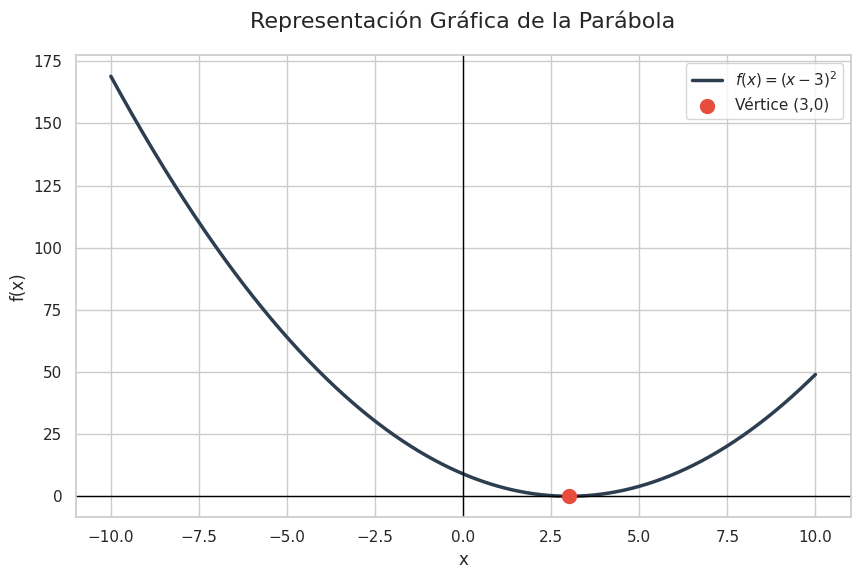

In [ ]:

y_1 = f_1(dom_f1)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


ax = sns.lineplot(x=dom_f1, y=y_1, color="#2c3e50", linewidth=2.5, label='$f(x) = (x-3)^2$')

plt.scatter([3], [0], color="#e74c3c", s=100, zorder=5, label='Vértice (3,0)')

plt.title('Representación Gráfica de la Parábola', fontsize=16, pad=20)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.legend(frameon=True, facecolor='white')

plt.show()


#### Función no convexa


La segunda función es la versión unidimensional de la función de Schwefel:

$$f_2(x) = -x \cdot \sin(\sqrt{|x|}), \quad x \in [-512, 512]$$

Esta función presenta desafíos considerablemente mayores:

- **Multimodal**: posee múltiples óptimos locales distribuidos en todo el dominio
- **No convexa**: presenta numerosos valles y picos
- **Óptimo global**: ubicado aproximadamente en $x^* \approx 420.97$ con $f(x^*) \approx -418.98$
- **Engañosa**: el óptimo global está lejos del origen y los óptimos locales están distribuidos asimétricamente
- **Gradiente**: $\nabla f_2(x) = -\sin(\sqrt{|x|}) - \frac{x \cos(\sqrt{|x|})}{2\sqrt{|x|}}$ (cuidado con $x=0$)

La función de Schwefel es particularmente desafiante porque el óptimo global está alejado de la región central, y existen múltiples óptimos locales que pueden atrapar algoritmos de búsqueda local.

> Implemente la función $f_2$ en Python y genere un gráfico que muestre su comportamiento en su dominio. Observe la distribución de óptimos locales.

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_990/1267593109.py:9: SyntaxWarning: invalid escape sequence '\s'
  label='$f(x) = -x \sin(\sqrt{|x|})$')


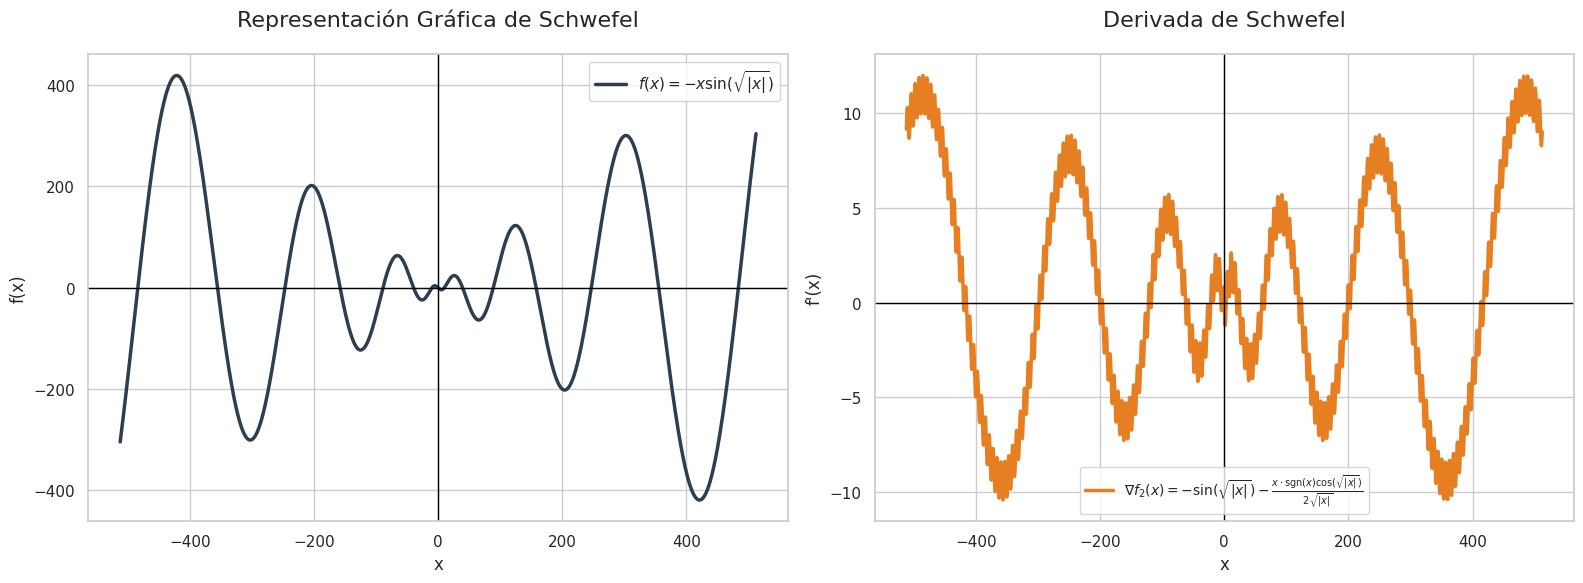

In [ ]:

y_1 = f_2(dom_f2)
y_2 = grad_f_2(dom_f2)

sns.set_theme(style="whitegrid")

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(x=dom_f2, y=y_1, ax=axs[0], color="#2c3e50", linewidth=2.5,
             label='$f(x) = -x \sin(\sqrt{|x|})$')
axs[0].set_title('Representación Gráfica de Schwefel', fontsize=16, pad=20)
axs[0].set_xlabel('x', fontsize=12)
axs[0].set_ylabel('f(x)', fontsize=12)
axs[0].axhline(0, color='black', linewidth=1)
axs[0].axvline(0, color='black', linewidth=1)
axs[0].legend(frameon=True, facecolor='white')

label_grad = r'$\nabla f_2(x) = -\sin(\sqrt{|x|}) - \frac{x \cdot \mathrm{sgn}(x) \cos(\sqrt{|x|})}{2\sqrt{|x|}}$'
sns.lineplot(x=dom_f2, y=y_2, ax=axs[1], color="#e67e22", linewidth=2.5, label=label_grad)
axs[1].set_title('Derivada de Schwefel', fontsize=16, pad=20)
axs[1].set_xlabel('x', fontsize=12)
axs[1].set_ylabel('f\'(x)', fontsize=12)
axs[1].axhline(0, color='black', linewidth=1)
axs[1].axvline(0, color='black', linewidth=1)
axs[1].legend(frameon=True, facecolor='white', fontsize='small')

plt.tight_layout()
plt.show()

Hay una suerte de periodicidad en los minimos.

Si igualo a 0 el gradiente por partes, tenemos que:

$$f_2(x) = \begin{cases} -x \sin(\sqrt{x}), & \text{si } x > 0 \\ -x \sin(\sqrt{-x}), & \text{si } x < 0 \end{cases}$$


Si derivamos ambas partes

$$f'_2(x) = \begin{cases} -\sin(\sqrt{x}) - \frac{\sqrt{x}}{2} \cos(\sqrt{x}), & \text{si } x > 0 \\ -\sin(\sqrt{-x}) - \frac{\sqrt{-x}}{2} \cos(\sqrt{-x}), & \text{si } x < 0 \end{cases}$$

Inspeccionaremos la periocidad en los minimso

$$$$


$$\begin{align}
0 &= -\sin(\sqrt{x}) - \frac{\sqrt{x}}{2} \cos(\sqrt{x})\\
\tan(\sqrt x) &= -\frac{\sqrt{x}}{2} \quad \text{ Definimos }z = \sqrt{x}\\
\tan{z}&=-\frac{z}{2}
\end{align}$$

Es decir, los optimos se dan en la intersección de ambas rectas.

Un analisis similar para para $x<0$ llega a los mismos resultados.


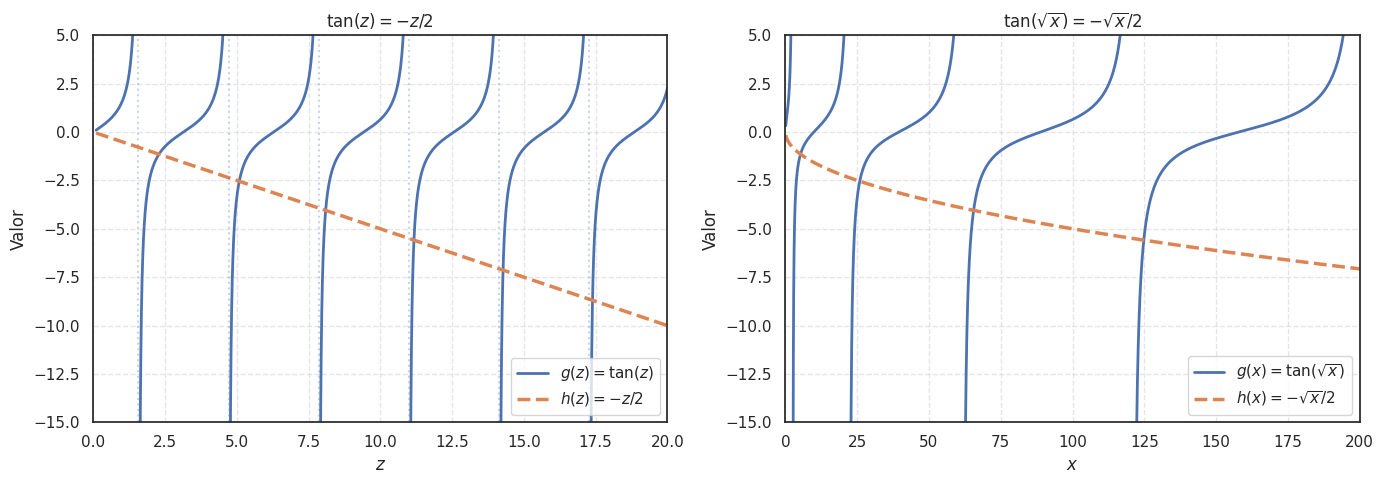

In [ ]:

sns.set_theme(style="white")
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
z = np.linspace(0.1, 20, 10000)

y_tan_z = np.tan(z)
y_recta_z = -z / 2

threshold = 50
y_tan_z[np.abs(y_tan_z) > threshold] = np.nan

axs[0].plot(z, y_tan_z, label=r'$g(z) = \tan(z)$', linewidth=2)
axs[0].plot(z, y_recta_z, label=r'$h(z) = -z/2$', linestyle='--', linewidth=2.5)

for i in range(1, 7):
    axs[0].axvline(x=(2*i-1)*np.pi/2, linestyle=':', alpha=0.3)

axs[0].set_title(r'$\tan(z) = -z/2$')
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel('Valor')
axs[0].set_xlim(0, 20)
axs[0].set_ylim(-15, 5)
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

x = np.linspace(0.1, 200, 10000)

y_tan_x = np.tan(np.sqrt(x))
y_recta_x = -np.sqrt(x) / 2

y_tan_x[np.abs(y_tan_x) > threshold] = np.nan

axs[1].plot(x, y_tan_x, label=r'$g(x) = \tan(\sqrt{x})$', linewidth=2)
axs[1].plot(x, y_recta_x, label=r'$h(x) = -\sqrt{x}/2$', linestyle='--', linewidth=2.5)

axs[1].set_title(r'$\tan(\sqrt{x}) = -\sqrt{x}/2$')
axs[1].set_xlabel(r'$x$')
axs[1].set_ylabel('Valor')
axs[1].set_xlim(0, 200)
axs[1].set_ylim(-15, 5)
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()


plt.tight_layout()
plt.show()

Los minimos ocurren cada vez mas lejos!
$$\begin{align}
\text{Si } z_{min} ≈ n - \pi/2 \implies x_{min} ≈ (n - \pi/2)^2
\end{align}$$
(Digo que cuando n crece, la z se acerca mas a la asintota)

Analogamente, podriamos hacer esto para x<0

Y por la naturaleza de esta funcion, los minimos y maximos estan intercalados, con los minimos cada vez menores, y los maximos cada vez mayores.

---

In [ ]:
best_experiments ={} #aca vamos a guardar los mejores resultados de cada algoritmos

## Sección 1: Búsqueda Aleatoria (*Random Search*)


La búsqueda aleatoria es el método más simple de optimización estocástica. Su estrategia consiste en muestrear puntos uniformemente al azar en el espacio de búsqueda y retornar el mejor encontrado. A pesar de su simplicidad, sirve como línea base fundamental para evaluar algoritmos más sofisticados y puede ser sorprendentemente efectivo en ciertos escenarios.

### 1.1 Fundamentos del algoritmo



El algoritmo de búsqueda aleatoria evalúa $N$ puntos generados aleatoriamente en el dominio de búsqueda y retorna la mejor solución encontrada. Su principal ventaja radica en que no requiere información sobre el gradiente, es trivialmente paralelizable y no puede quedar atrapado en óptimos locales. Sin embargo, su eficiencia decrece rápidamente al aumentar la dimensionalidad del problema.

$$
\begin{array}{ll}
\hline
\textbf{Algoritmo:} & \textbf{Búsqueda Aleatoria (Random Search)} \\
\hline
\textbf{Entrada:} & \text{Intervalo } [a, b], \text{ número de evaluaciones } N \\
\textbf{Salida:} & \text{Mejor solución } x^* \text{ y su fitness } f(x^*) \\
\hline
\end{array}
$$
$$
\begin{array}{ll}
1: & x_{\text{best}} \leftarrow \text{null} \\
2: & f_{\text{best}} \leftarrow \infty \\
3: & \textbf{for } i = 1 \text{ to } N \textbf{ do} \\
4: & \quad x_i \leftarrow U(a, b) \quad \triangleright \text{ Muestreo uniforme en } [a, b] \\
5: & \quad f_i \leftarrow f(x_i) \\
6: & \quad \textbf{if } f_i < f_{\text{best}} \textbf{ then} \\
7: & \quad \quad x_{\text{best}} \leftarrow x_i \\
8: & \quad \quad f_{\text{best}} \leftarrow f_i \\
9: & \quad \textbf{end if} \\
10: & \textbf{end for} \\
11: & \textbf{return } (x_{\text{best}}, f_{\text{best}})
\end{array}
$$

El hiperparámetro $N$ controla el balance entre costo computacional y probabilidad de encontrar buenas soluciones. Valores mayores de $N$ aumentan la cobertura del espacio de búsqueda pero incrementan el tiempo de ejecución linealmente.


> Implemente el algoritmo de búsqueda aleatoria.



In [ ]:
def random_search(N, dominio, function):

  n = len(dominio)

  x_best = None
  fbest = np.inf

  posiciones = random.sample(range(n), N)
  for curr in posiciones:
    f = function(dominio[curr])

    if (fbest > f):
      fbest = f
      x_best = dominio[curr]

  return (x_best, fbest)



### 1.2 Implementación con visualización en tiempo real


La visualización en tiempo real permite comprender intuitivamente cómo el algoritmo explora el espacio de búsqueda.

> Implemente una función que anime el proceso de optimización mediante una visualización con dos paneles:
> - **Panel izquierdo**: Evolución del mejor fitness encontrado a lo largo de las iteraciones. Este gráfico muestra cómo la calidad de la solución mejora (o se estanca) con cada nueva evaluación.
>- **Panel derecho**: Posición de las soluciones evaluadas sobre el gráfico de la función objetivo. Distinga visualmente la mejor solución encontrada hasta el momento usando un marcador de diferente color, tamaño o forma.
>**Recomendaciones**:
> - Utilice `matplotlib` con modo interactivo (`plt.ion()`) para actualización en tiempo real
> - Implemente pausas breves entre frames (`plt.pause(0.05)`) para visualizar la progresión
> - Incluya información textual relevante: iteración actual, mejor fitness, mejor $x$ encontrado


> Ejecute el algoritmo para $f_1$ con $N=100$ y observe el comportamiento. Repita para $f_2$ y note las diferencias en el patrón de búsqueda.


In [ ]:
def make_animated_optimization_RS(dominio, function):

  """
  Codigo encargado de hacer la animacion del proceso iterativo
  """

  np.random.seed(42)
  N=5
  print("Mínimos encontrados\n")

  y_f1 = function(dominio) #esto es para el dibujo

  best_hist = []

  total_iter = 100
  step = 5
  range_iter = int(total_iter/step)

  for i in range(range_iter):
      x_min, y_min = random_search(N,dominio,function)

      best_hist.append([N,x_min,y_min])
      N+=step

      clear_output(wait=True)
      fig, axes = plt.subplots(1, 2, figsize=(16, 7))

      #fitness
      axes[0].set_title("Fitness", fontsize=14, pad=10)
      axes[0].set_xlim(0,total_iter)
      axes[0].set_xlabel("N")
      axes[0].set_ylabel("y_min")

      data = np.array(best_hist)

      sns.lineplot(x=data[:,0], y=data[:,2], ax=axes[0])
      sns.lineplot(x=dominio,y=y_f1, ax=axes[1])
      sns.scatterplot(x=data[:,1],y=data[:,2],ax=axes[1], color='red')
      axes[1].set_title("Función", fontsize=14, pad=10)
      axes[1].set_xlabel("x")
      axes[1].set_ylabel("f2(x)")

      plt.tight_layout()
      plt.show()

  for record in best_hist:
      n,x,y = record
      print(f"N={n} ({np.round(x,2)},{np.round(y,2)})")


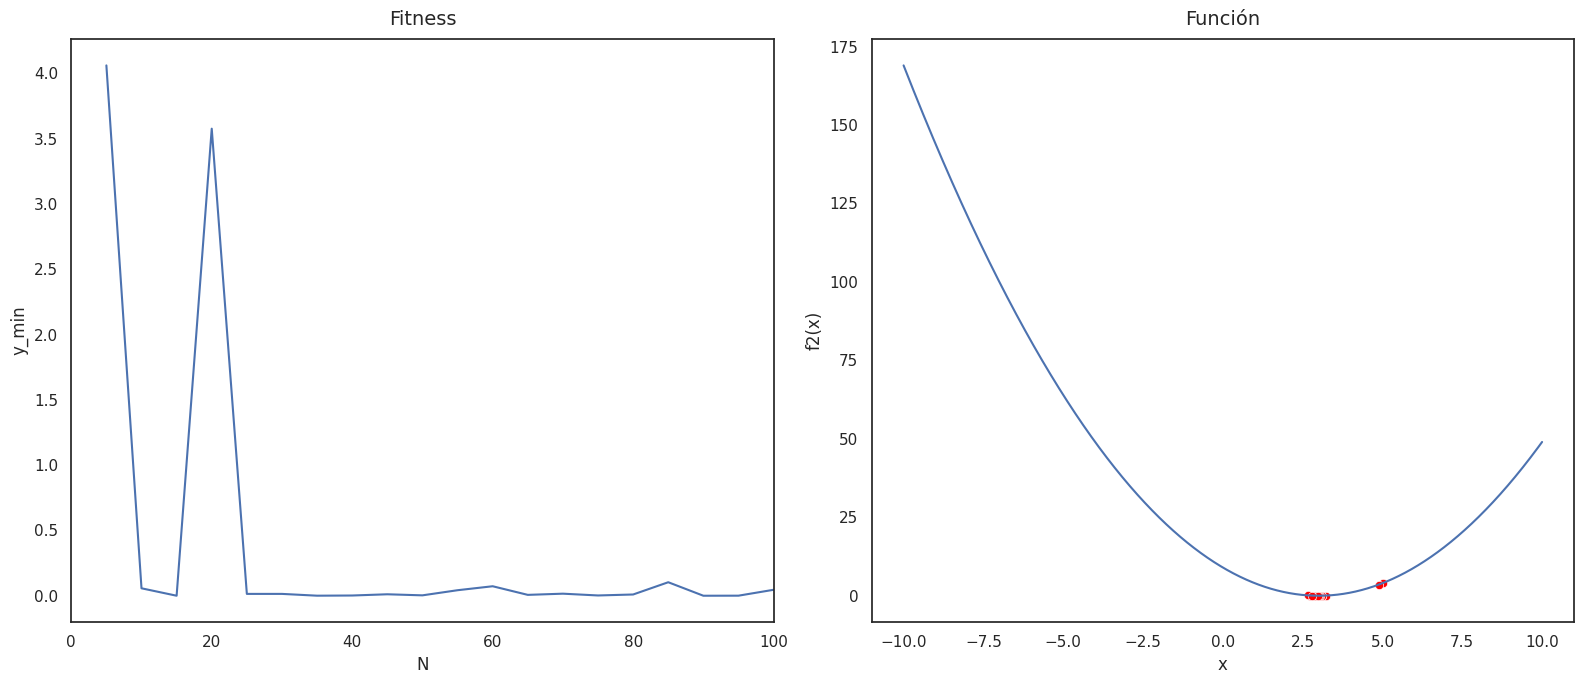

N=5 (5.02,4.06)
N=10 (3.24,0.06)
N=15 (2.99,0.0)
N=20 (4.89,3.58)
N=25 (3.12,0.01)
N=30 (3.12,0.01)
N=35 (3.02,0.0)
N=40 (2.96,0.0)
N=45 (2.89,0.01)
N=50 (3.05,0.0)
N=55 (2.79,0.04)
N=60 (2.73,0.07)
N=65 (2.92,0.01)
N=70 (2.87,0.02)
N=75 (2.95,0.0)
N=80 (2.9,0.01)
N=85 (2.68,0.1)
N=90 (3.0,0.0)
N=95 (2.98,0.0)
N=100 (2.79,0.05)


In [ ]:
make_animated_optimization_RS(dom_f1, f_1)

### 1.3 Análisis de hiperparámetros en función convexa

El objetivo de esta sección es comprender cómo el número de evaluaciones $N$ afecta el desempeño del algoritmo en un problema simple.

> Ejecute el algoritmo de búsqueda aleatoria para minimizar $f_1(x) = (x-3)^2$ en el intervalo $[-10, 10]$, explorando los siguientes valores del hiperparámetro:
> $$N \in \{10, 50, 100, 500, 1000, 5000\}$$
> Para cada valor de $N$, realice **10 repeticiones independientes** y registre en cada ejecución:
> - Mejor fitness alcanzado: $f(x^*)$
> - Posición de la mejor solución: $x^*$
> - Tiempo de ejecución en segundos

> Para cada valor de $N$, calcule las siguientes estadísticas sobre las 10 repeticiones:
> - **Media ± Intervalo de Confianza (IC)**: $\bar{x} \pm 1.96 \frac{\sigma}{\sqrt{n}}$, donde $\bar{x}$ es el promedio, $\sigma$ la desviación estándar y $n=10$
> - **Mediana**: valor central de la distribución
> - **Mejor resultado**: mínimo obtenido en las 10 ejecuciones
> Complete la siguiente tabla:


| N | Fitness: Media ± IC | Fitness: Mediana | Fitness: Mejor | Tiempo [s]: Media ± IC | Tiempo [s]: Mediana | Tiempo [s]: Mejor |
|:---:|:-----------------:|:----------------:|:--------------:|:----------------------:|:-------------------:|:-----------------:|
| 10 | ... | ... | ... | ... | ... | ... |
| 50 | ... | ... | ... | ... | ... | ... |
| ... | ... | ... | ... | ... | ... | ... |


> Además, genere las siguientes visualizaciones:
> 1. Gráfico de boxplot con la distribución del fitness final para cada valor de $N$.
> 2. Gráfico de barras mostrando el tiempo de ejecución promedio vs $N$. Incluya los bigotes de dispersión para cada barra (valor del intervalo de confianza).


**Preguntas de análisis**:

1. ¿Qué valor de $N$ proporciona el mejor balance entre calidad de solución y tiempo de cómputo?
2. ¿A partir de qué valor de $N$ las mejoras en fitness se vuelven marginales?
3. ¿La variabilidad (dispersión) de los resultados disminuye al aumentar $N$? ¿Por qué?
4. Dado que el óptimo es conocido ($x^*=3$, $f(x^*)=0$), ¿qué tan cerca llegan las soluciones encontradas?

#### resultados

In [ ]:
def make_experiment_random_search(total_n, k, dominio, function):

  """
  Genera un diccionario con la siguiente estructura para el experimento para la funcion
        {
          clave: N del experimento
          valor: Diccionario interno{
            x: Lista de x encontrados en las k tiradas del random_search en N]
            y: Lista de y encontrados en las k tiradas del random_search en N]
            t: Lista de tiempos tardados en las k tiradas del random_search en N]
          }
        }
  """
  #N_s=[10,50,100,500,1000,5000]
  #k = 10
  results = {}

  for n in N_s:
    current_x = []
    current_y = []
    current_time = []
    for i in range(k):
      start_time = time.time()
      x_best, y_best = random_search(n, dominio, function)
      end_time = time.time()

      current_x.append(x_best)
      current_y.append(y_best)
      current_time.append(end_time - start_time)


    aux = {}
    aux["x"] = current_x
    aux["y"] = current_y
    aux["t"] = current_time

    results[str(n)] = aux

  return results

def info_experiment_random_search(results, umbral):
  """
  Esta funcion genera un resumen del experimento con la informacion:
    N
    Mejor fitness
    media fitness + IC del 95% de cofnanza
    mejor tiempo
    media_tiempo + IC 95% de confianza
    mediana tiempo
    tasa de exito < a un cierto umbral
  """
  rows = []

  for n in results:
      #fitnes
      y_min = round(np.min(results[n]["y"]), 5)
      y_media = np.mean(results[n]["y"])
      ic_y = 1.96 * np.std(results[n]["y"], ddof=1) / 10
      y_mediana = round(np.median(results[n]["y"]), 5)

      #tiempo
      t_min = round(np.min(results[n]["t"]), 5)
      t_media = np.mean(results[n]["t"])
      ic_t = 1.96 * np.std(results[n]["t"], ddof=1) / 10
      t_mediana = round(np.median(results[n]["t"]), 5)

      tasa_exito = (len(np.where(np.array(results[n]['y']) < umbral)[0])/10)*100

      row = {
          "N": int(n),
          "mejor_fitness": y_min,
          "media_fitness + IC": f"{y_media} +- {ic_y:.6f}",
          "mediana_fitness": y_mediana,
          "mejor_tiempo": t_min,
          "media_tiempo+ IC": f"{t_media} +- {ic_t:.6f}",
          "mediana_tiempo": t_mediana,
          "tasa_exito": tasa_exito
      }

      rows.append(row)

  df = pd.DataFrame(rows)
  return df


def buscar_mejor_rs(results):
  n_min = 0
  min = np.inf
  for n in results:
    idx_min = np.argmin(results[n]['y'])
    curr_fit = results[n]['y'][idx_min]
    if curr_fit <min:
      min = curr_fit
      n_min = n

  return {'N': n_min}


In [ ]:
N_s=[10,50,100,500,1000,5000]
repeat = 10

results = make_experiment_random_search(
    total_n = N_s,
    k=repeat,
    dominio=dom_f1,
    function=f_1)

print(results) #no se entiende nada

df = info_experiment_random_search(
    results,
    umbral = 0.1
)

best_experiments['RS_cvx'] = buscar_mejor_rs(results)
print(best_experiments)
df



{'10': {'x': [np.float64(3.8947789557911587), np.float64(2.8425685137027408), np.float64(2.390478095619123), np.float64(2.098419683936788), np.float64(3.626725345069014), np.float64(2.854570914182837), np.float64(2.2584516903380685), np.float64(3.734746949389878), np.float64(2.7745549109821965), np.float64(2.18243648729746)], 'y': [np.float64(0.8006293797267164), np.float64(0.02478467287776412), np.float64(0.37151695192009077), np.float64(0.8128470663126414), np.float64(0.3927846581518744), np.float64(0.021149619001615813), np.float64(0.5498938955624679), np.float64(0.5398530796377322), np.float64(0.05082548816224533), np.float64(0.668410097302516)], 't': [7.2479248046875e-05, 2.8848648071289062e-05, 2.4318695068359375e-05, 2.0742416381835938e-05, 2.0742416381835938e-05, 2.1696090698242188e-05, 2.4080276489257812e-05, 2.193450927734375e-05, 2.2172927856445312e-05, 2.2411346435546875e-05]}, '50': {'x': [np.float64(3.142628525705142), np.float64(2.9825965193038613), np.float64(2.73454690

,N,mejor_fitness,media_fitness + IC,mediana_fitness,mejor_tiempo,media_tiempo+ IC,mediana_tiempo,tasa_exito
0,10,0.02115,0.4232694908655665 +- 0.060117,0.46632,0.00002,2.7942657470703126e-05 +- 0.000003,0.00002,30.0
1,50,0.00030,0.10431392139600151 +- 0.025726,0.04700,0.00007,8.459091186523438e-05 +- 0.000002,0.00008,60.0
2,100,0.00001,0.009133773143906652 +- 0.002658,0.00345,0.00015,0.0004996299743652344 +- 0.000211,0.00016,100.0
3,500,0.00000,0.0002902360828236888 +- 0.000098,0.00004,0.00067,0.0008710622787475586 +- 0.000060,0.00077,100.0
4,1000,0.00000,0.00010072028408482103 +- 0.000029,0.00004,0.00139,0.0015267133712768555 +- 0.000012,0.00155,100.0
5,5000,0.00000,1.9607842352612512e-06 +- 0.000000,0.00000,0.00687,0.0072704792022705075 +- 0.000047,0.00728,100.0


Resultados:
1. Algunos se aproximaron a la solucion casi de manera exacta en alguna iteración. Entre mas iteraciones (N), mas probabilidad de obtener un "mejor_fitness" proximo a cero.
2. El tiempo incrementa a medida que las cantidad de iteraciones crece. Random search es un algoritmo lineal y se puede ver la linealidad del algoritmo respecto a la cantidad de entradas con la mediana del tiempo. Por ejemplo
$$\begin{align}
&N=10 \implies 0.00002 \text{ s}\\
&N= 1000 \implies  1000*0.00002 /10= 0.002 \text{ s} \approx 0.00161
\end{align}$$

$$$$

Para comprender otros patrones, podemos inspeccionar una serie de graficos


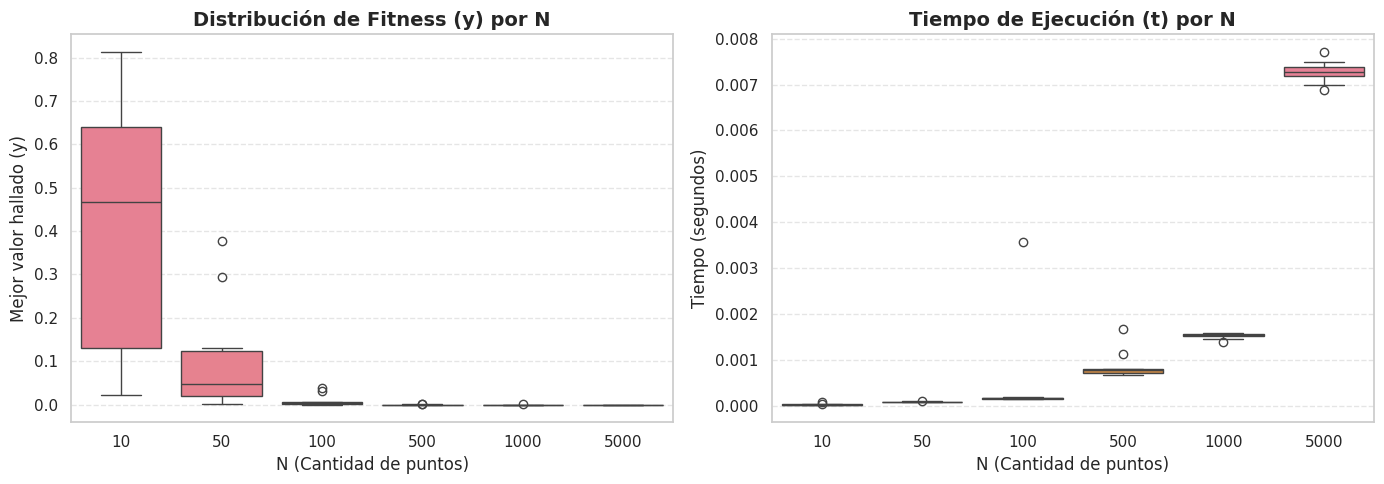

In [ ]:
datos_fitness = []
datos_tiempo = []

for n in N_s:
    for y in results[str(n)]['y']:
        datos_fitness.append({'N': n, 'Fitness': y})
    for t in results[str(n)]['t']:
        datos_tiempo.append({'N': n, 'Tiempo': t})

df_fitness = pd.DataFrame(datos_fitness)
df_tiempo = pd.DataFrame(datos_tiempo)

# Configurar estilo de seaborn
sns.set_style("whitegrid")
colors = sns.color_palette("husl", len(N_s))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
# boxplot fitness
sns.boxplot(data=df_fitness, x='N', y='Fitness', ax=axs[0], hue='N', palette='husl', legend=False)
axs[0].set_title('Distribución de Fitness (y) por N', fontsize=14, fontweight='bold')
axs[0].set_xlabel('N (Cantidad de puntos)', fontsize=12)
axs[0].set_ylabel('Mejor valor hallado (y)', fontsize=12)
axs[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# boxplot de tiempo
sns.boxplot(data=df_tiempo, x='N', y='Tiempo', ax=axs[1], hue='N', palette='husl', legend=False)
axs[1].set_title('Tiempo de Ejecución (t) por N', fontsize=14, fontweight='bold')
axs[1].set_xlabel('N (Cantidad de puntos)', fontsize=12)
axs[1].set_ylabel('Tiempo (segundos)', fontsize=12)
axs[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



- **tamaño de muestra**: N es el tamaño de la busqueda para hacerla muestra. Al trabajar con una muestra pequeña (ejemplo N=10), es mas probable no llegar a un optimo proximo a la mejor solución debido a que son pocos puntos por experimentos. A medida que se incrementa la cantidad de muestra en el experimento, los fintess reducen su varianza.

- **tiempo**: inversamente,a medida que incrementamos mas el tamaño de la muestra, mas dispersion se nota en la dimension temporal y mayor presencia de outliers. ¿Por qué crece el desvio?

#### Test estadisticos

respondiendo a:
- ¿A partir de qué valor de  N  las mejoras en fitness se vuelven marginales?
Se nos ocurre hacer una "diferencia de medias entre los rendimientos consecutivos de N, para saber si hay diferencia significativas entre esos datos.


Primero verificamos supuestos para saber si es posible plantear test estadisticos parametricos. A saber:
- Normalidad de los residuos
- Varianza homogenea
- independencia de las observaciones (ya que estamos evaluando un algoritmo con diferentes datos).

Aun asi probamos los otros supuestos.

In [ ]:
# verificamos supuestos
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#hacemos el anova
datos_fitness = []
for n in N_s:
    for y in results[str(n)]['y']:
        datos_fitness.append({'N': n, 'Fitness': y})

df = pd.DataFrame(datos_fitness)

modelo = ols('Fitness ~ C(N)', data=df).fit()
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues


# normalidad de los residuos
print("shapiro wilk, normalidad de los residuos")
for n in N_s:
    data = results[str(n)]['y']
    shapiro_stat, p_val = stats.shapiro(data)
    status = "Normal" if p_val > 0.05 else "NO Normal"
    print(f"N={n:4}: p-val={p_val:.4f} -> {status}")
print()

# homocedasticidad,
data_groups = [results[str(n)]['y'] for n in N_s]
levene_stat, p_val_levene = stats.levene(*data_groups)
status_levene = "Varianzas iguales" if p_val_levene > 0.05 else "Varianzas DIFERENTES"
print(f"Levene test: p-val={p_val_levene:.6f} -> {status_levene}")
print()

shapiro wilk, normalidad de los residuos
N=  10: p-val=0.1839 -> Normal
N=  50: p-val=0.0098 -> NO Normal
N= 100: p-val=0.0003 -> NO Normal
N= 500: p-val=0.0002 -> NO Normal
N=1000: p-val=0.0014 -> NO Normal
N=5000: p-val=1.0000 -> Normal

Levene test: p-val=0.000000 -> Varianzas DIFERENTES



/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


No cumple nada, asi que optaremos por hacer un test no parametros. Vamos a hacer wilcoxxon con el objetivo de hacer diferencia significativa de medianas entre grupos consecutivos.

Para ellos vamos a probar con un test de friedmann que plantea

$$\begin{align}
&H_0: \text{Todas las medianas de los grupos son iguales}\\
&H_1: \text{al menos existe una diferencia}
\end{align}$$

In [ ]:
import pandas as pd
from scipy.stats import friedmanchisquare

data_matrix = {str(n): results[str(n)]['y'] for n in N_s}

df_friedman = pd.DataFrame(data_matrix)

stat, p_value = friedmanchisquare(*[df_friedman[col] for col in df_friedman.columns])

print(f"Estadístico de Friedman: {stat:.4f}")
print(f"P-valor: {p_value:.4e}")

if p_value < 0.05:
    print("Rechazamos H0: Hay diferencias significativas entre los valores de N.")
else:
    print("No hay evidencia suficiente para decir que cambiar N afecte el rendimiento.")

Estadístico de Friedman: 44.1931
P-valor: 2.1163e-08
Rechazamos H0: Hay diferencias significativas entre los valores de N.


In [ ]:
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

p_values_adj = []
labels = []

cols = df_friedman.columns
for i in range(len(cols) - 1):
  _, p = wilcoxon(df_friedman[cols[i]], df_friedman[cols[i+1]])
  p_values_adj.append(p)
  labels.append(f"{cols[i]} vs {cols[i+1]}")

# 4. Corrección de Bonferroni para las comparaciones realizadas
reject, p_corrected, _, _ = multipletests(p_values_adj, method='bonferroni')

print("\nResultados de Comparaciones Adyacentes:")
for label, p_adj, sig in zip(labels, p_corrected, reject):
  status = "Diferencia Significativa" if sig else "Diferencia MARGINAL (No significativa)"
  print(f"{label}: {status} (p-adj: {p_adj:.4f})")


Resultados de Comparaciones Adyacentes:
10 vs 50: Diferencia Significativa (p-adj: 0.0195)
50 vs 100: Diferencia MARGINAL (No significativa) (p-adj: 0.0977)
100 vs 500: Diferencia Significativa (p-adj: 0.0293)
500 vs 1000: Diferencia MARGINAL (No significativa) (p-adj: 1.0000)
1000 vs 5000: Diferencia Significativa (p-adj: 0.0391)


El análisis post-hoc revela que el algoritmo presenta rendimientos decrecientes a partir de $N = 500$. Si bien existen saltos significativos iniciales, el incremento del presupuesto computacional por encima de 500 (incluso multiplicándolo por 10 para llegar a 5000) no produce una mejora estadísticamente significativa en el fitness ($p > 0.05$). Por lo tanto, $N = 500$ se identifica como el punto de eficiencia óptima, donde se maximiza el rendimiento sin incurrir en un gasto computacional innecesario.

### 1.4 Análisis de hiperparámetros en función no convexa

Ahora evaluamos el desempeño de Random Search en un problema significativamente más desafiante: la función multimodal de Schwefel.

> Ejecute el algoritmo para minimizar $f_2(x)$, utilizando los mismos valores de $N$ que en la sección anterior. Realice **10 repeticiones** por cada valor de $N$ y registre las mismas métricas: mejor fitness, posición $x^*$ y tiempo de ejecución.


> Complete una tabla idéntica a la de la sección 1.3, e incorpore la **tasa de éxito** para cada valor de $N$:
> $$\text{Tasa de éxito} = \frac{\text{Número de ejecuciones con } f(x^*) < -400}{10} \times 100\%$$
> El umbral $f(x^*) < -400$ representa soluciones "cercanas" al óptimo global ($f_{\text{opt}} \approx -418.98$), permitiendo cuantificar qué tan frecuentemente el algoritmo encuentra buenas soluciones.

| N | Fitness: Media ± IC | Fitness: Mediana | Fitness: Mejor | Tiempo [s]: Media ± IC | Tasa éxito [%] |
|:---:|:-----------------:|:----------------:|:--------------:|:----------------------:|:--------------:|
| 10 | ... | ... | ... | ... | ... |
| 50 | ... | ... | ... | ... | ... |
| ... | ... | ... | ... | ... | ... |



> Además, genere las siguientes visualizaciones:
> 1. Figura con 6 subpaneles (uno por cada valor de $N$), mostrando en cada uno la función $f_2$, y las 10 soluciones finales $x^*$ encontradas en las repeticiones superpuestas (como puntos o marcas verticales). Use colores para distinguir soluciones exitosas ($f(x^*) < -400$) de las que quedaron atrapadas en óptimos locales.
> 2. Boxplot comparativo mostrando la distribución del fitness final para cada valor de $N$, similar a la sección 1.3.
> 3. Gráfico de barras mostrando cómo la tasa de éxito varía con $N$. ¿Es monótona esta relación?
> 4. Histograma de soluciones para el mejor valor de $N$, mostrando la distribución espacial de las soluciones $x^*$ encontradas. ¿Se concentran en alguna región particular o se distribuyen uniformemente?


In [ ]:
N_s=[10,50,100,500,1000,5000]
repeat = 10

results = make_experiment_random_search(
    total_n = N_s,
    k = repeat,
    dominio = dom_f2,
    function = f_2
)


best_experiments['RS_non_cvx']= buscar_mejor_rs(results)
print(best_experiments)
df = info_experiment_random_search(results, -400)
df



{'RS_cvx': {'N': '500'}, 'RS_non_cvx': {'N': '500'}}


,N,mejor_fitness,media_fitness + IC,mediana_fitness,mejor_tiempo,media_tiempo+ IC,mediana_tiempo,tasa_exito
0,10,-418.81691,-290.18646482767724 +- 19.511734,-283.07108,0.00007,8.287429809570313e-05 +- 0.000005,0.00007,20.0
1,50,-418.91428,-393.81125024034117 +- 7.807338,-412.08913,0.00033,0.0004754781723022461 +- 0.000064,0.00036,80.0
2,100,-418.92168,-412.3388095898719 +- 1.631383,-416.07695,0.00062,0.001183462142944336 +- 0.000203,0.00081,80.0
3,500,-418.98204,-418.7709521445533 +- 0.055613,-418.90899,0.00242,0.0034054279327392577 +- 0.000092,0.00356,100.0
4,1000,-418.98204,-418.95969642023493 +- 0.006874,-418.97675,0.00671,0.006955742835998535 +- 0.000065,0.00682,100.0
5,5000,-418.98204,-418.9820416049978 +- 0.000000,-418.98204,0.03413,0.03541269302368164 +- 0.000165,0.03536,100.0


Podemos inspeccionar que a medida que incrementamos el N; mas soluciones tienden a aproximarse a lo que venia a ser el umbral de fitness para considerar la zona de densidad suficiente.

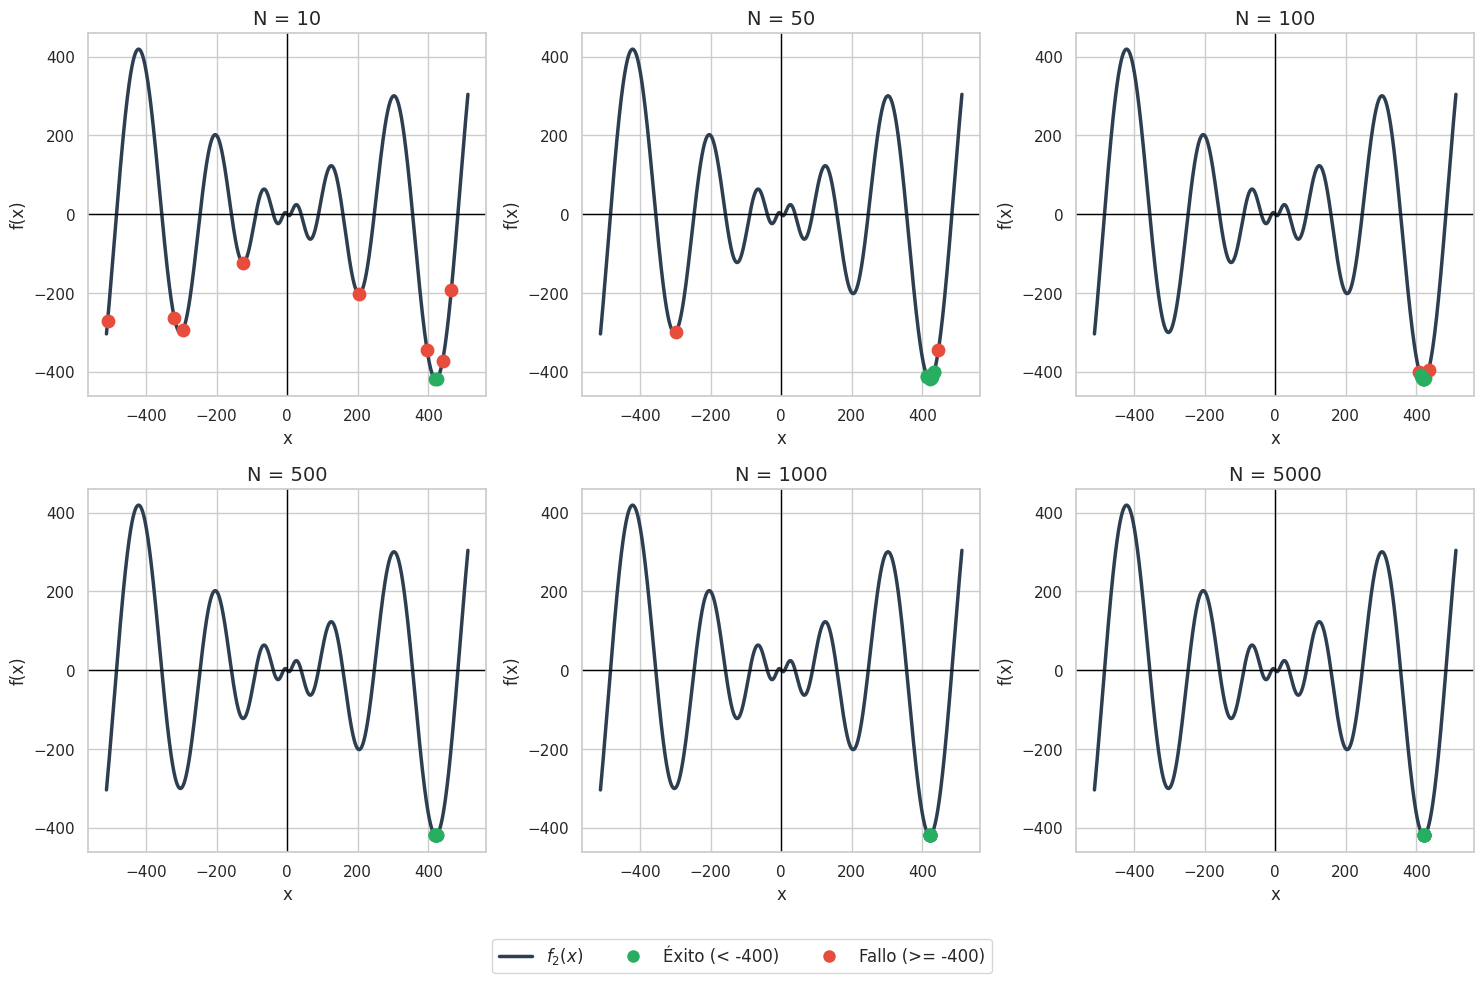

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
y_2 = f_2(dom_f2)
axs_flat = axs.flatten()


color_linea = "#2c3e50"
color_exito = "#27ae60"
color_fallo = "#e74c3c"

for i in range(len(axs_flat)):
    ax = axs_flat[i]
    n_value = N_s[i]

    ax.plot(dom_f2, y_2, color=color_linea, linewidth=2.5)
    ax.set_title(f'N = {n_value}', fontsize=14)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('f(x)', fontsize=12)
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)

    final_xs = results[str(n_value)]['x']
    final_ys = results[str(n_value)]['y']

    for x_val, y_val in zip(final_xs, final_ys):
        if y_val < -400:
            ax.scatter(x_val, y_val, color=color_exito, s=80, zorder=5)
        else:
            ax.scatter(x_val, y_val, color=color_fallo, s=80, zorder=5)


leyenda_elementos = [
    Line2D([0], [0], color=color_linea, lw=2.5, label='$f_2(x)$'),
    Line2D([0], [0], marker='o', color='w', label='Éxito (< -400)',
           markerfacecolor=color_exito, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Fallo (>= -400)',
           markerfacecolor=color_fallo, markersize=10)
]


fig.legend(handles=leyenda_elementos,
           loc='lower center',
           bbox_to_anchor=(0.5, 0.01),
           ncol=3,
           fontsize=12,
           frameon=True,
           facecolor='white')
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

Vemos que en los N mas chicos,queda atrapado en minimos locales. Justamente al ser un algoritmo que busca explorar el dominio de la funcion, puede conducir a resultados no tan optimos en un arranque.

/tmp/ipykernel_990/2848085575.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fitness, x='N', y='Fitness', ax=axs[0], palette='husl')
/tmp/ipykernel_990/2848085575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tiempo, x='N', y='Tiempo', ax=axs[1], palette='husl')


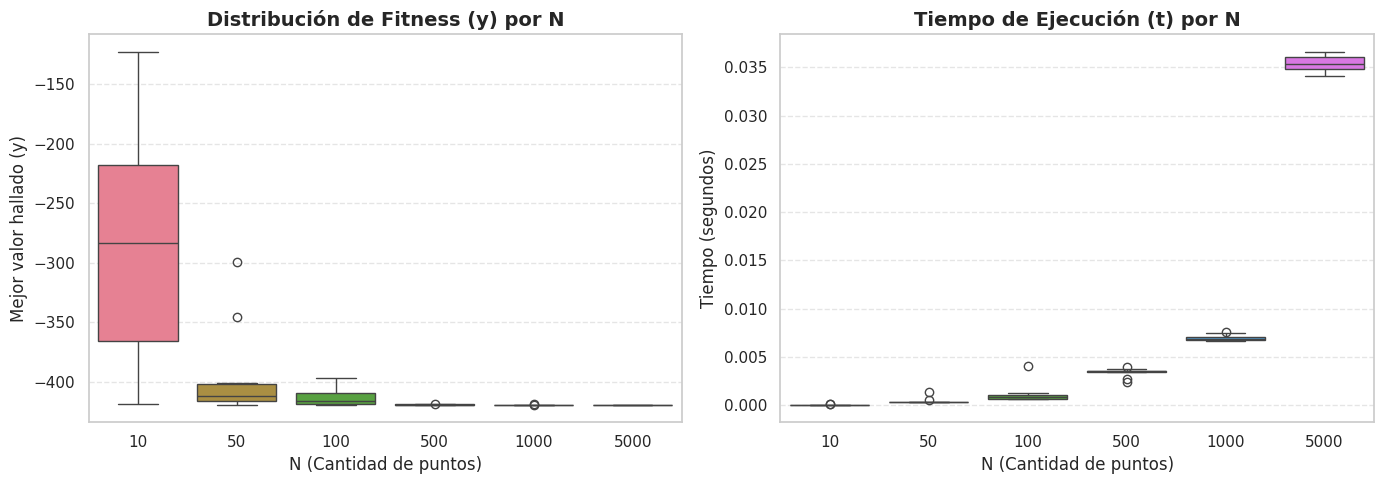

In [ ]:
datos_fitness = []
datos_tiempo = []

for n in N_s:
    for y in results[str(n)]['y']:
        datos_fitness.append({'N': n, 'Fitness': y})
    for t in results[str(n)]['t']:
        datos_tiempo.append({'N': n, 'Tiempo': t})

df_fitness = pd.DataFrame(datos_fitness)
df_tiempo = pd.DataFrame(datos_tiempo)

sns.set_style("whitegrid")
colors = sns.color_palette("husl", len(N_s))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))


#boxplot fitness
sns.boxplot(data=df_fitness, x='N', y='Fitness', ax=axs[0], palette='husl')
axs[0].set_title('Distribución de Fitness (y) por N', fontsize=14, fontweight='bold')
axs[0].set_xlabel('N (Cantidad de puntos)', fontsize=12)
axs[0].set_ylabel('Mejor valor hallado (y)', fontsize=12)
axs[0].grid(True, axis='y', linestyle='--', alpha=0.5)

#boxplot tiempo
sns.boxplot(data=df_tiempo, x='N', y='Tiempo', ax=axs[1], palette='husl')
axs[1].set_title('Tiempo de Ejecución (t) por N', fontsize=14, fontweight='bold')
axs[1].set_xlabel('N (Cantidad de puntos)', fontsize=12)
axs[1].set_ylabel('Tiempo (segundos)', fontsize=12)
axs[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



Le cuesta bastante mas con el N=10 que en la funcion convexa, justamente por la naturaleza senoidal de la funcion, que hace que tenga varios minimos locales. No solo en cuestion de fitnes sino tambien en cuestion de la varianza de este.

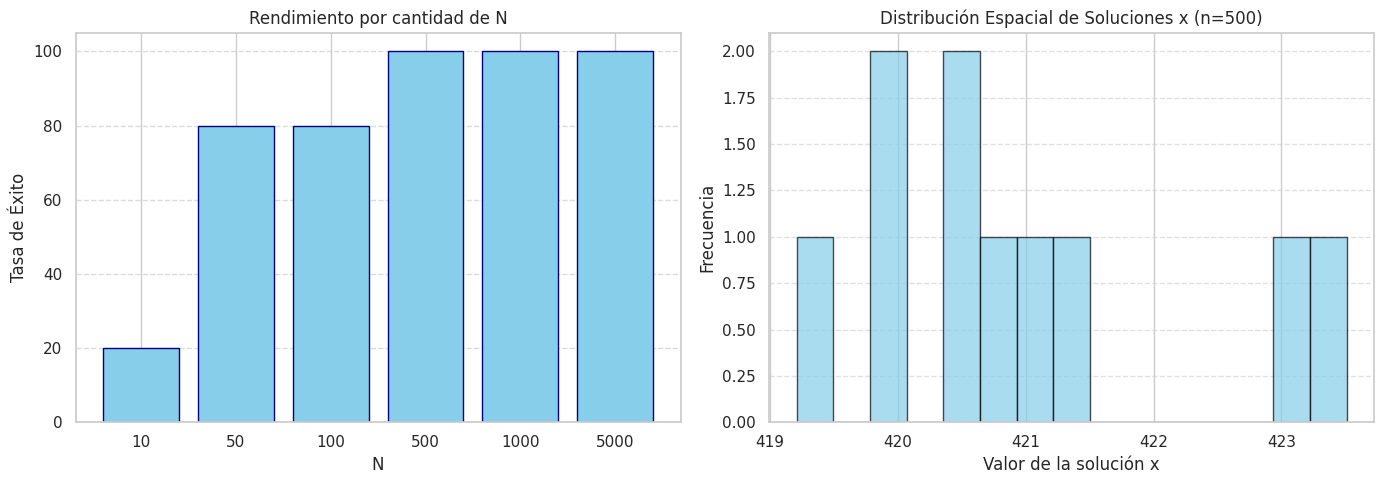

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


df['N'] = df['N'].astype(str)


n_target = "500"
datos_x = results[n_target]["x"]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.bar(df['N'], df['tasa_exito'], color='skyblue', edgecolor='navy')
ax1.set_xlabel('N')
ax1.set_ylabel('Tasa de Éxito')
ax1.set_title('Rendimiento por cantidad de N')
ax1.grid(axis='y', linestyle='--', alpha=0.7)


ax2.hist(datos_x, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
ax2.set_title(f'Distribución Espacial de Soluciones x (n={n_target})', fontsize=12)
ax2.set_xlabel('Valor de la solución x', fontsize=12)
ax2.set_ylabel('Frecuencia', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

estan todos alredederdor del minimo optimo!

**Preguntas de análisis**:

1. ¿Cómo se compara el fitness alcanzado con el óptimo global conocido? ¿Alguna ejecución lo encontró?
2. ¿Se necesita mayor o menor $N$ en comparación con la función convexa para alcanzar resultados satisfactorios?
3. ¿La presencia de múltiples óptimos locales aumenta significativamente la variabilidad de los resultados?
4. Observando el histograma de soluciones, ¿hay regiones del dominio que atraen más soluciones? ¿Por qué?
5. ¿La tasa de éxito justifica el uso de Random Search en problemas multimodales?

---

1. Si, varios algoritmos llegaron al valor exacto, a veces incluso aquel con N = 50
2. Se requiere un mayor N. En la funcion convexa, ya el algoritmo con N=10, llegaba a un valor bastante satisfactorio
3. Inspeccionando los graficos, vemos que para N pequeños aumenta la variabilidad de los resultados drasticamente. Para N mayores, no, pero esto implica mayor tiempo de ejecucion del algoritmo
4. Si hay regiones, pero varian con cada ejecucion del algoritmo
5. Si, solo por la tasa de exito pareciera funcionar siempre y cuando el N sea considerablemente grande. Es probable que otros factores como el tiempo sea un factor de analisis.

## Sección 2: Descenso por Gradiente con Momento (SGD)

El descenso por gradiente es uno de los métodos de optimización más fundamentales y ampliamente utilizados, especialmente en aprendizaje automático. A diferencia de *Random Search*, este algoritmo utiliza información local del paisaje de fitness (el gradiente) para guiar la búsqueda hacia regiones de menor valor. La incorporación de momento permite acelerar la convergencia y superar pequeñas irregularidades del paisaje.

### 2.1 Fundamentos del algoritmo

El descenso por gradiente con momento actualiza iterativamente una solución candidata moviéndose en la dirección opuesta al gradiente de la función objetivo. El componente de momento agrega "inercia" al movimiento, permitiendo que el algoritmo mantenga dirección en regiones relativamente planas y potencialmente escape de óptimos locales poco profundos.

La actualización en cada iteración se define como:

$$v_{t+1} = \beta \cdot v_t + \alpha \cdot \nabla f(x_t)$$
$$x_{t+1} = x_t - v_{t+1}$$

donde $\alpha$ es la tasa de aprendizaje (learning rate), $\beta$ es el coeficiente de momento, y $v_t$ representa la velocidad acumulada.

$$
\begin{array}{ll}
\hline
\textbf{Algoritmo:} & \textbf{Descenso por Gradiente con Momento (SGD + Momentum)} \\
\hline
\textbf{Entrada:} & \text{Punto inicial } x_0, \text{ tasa de aprendizaje } \alpha, \text{ momento } \beta, \\
& \text{tolerancia } \varepsilon, \text{ máximo de iteraciones } T_{\max} \\
\textbf{Salida:} & \text{Solución aproximada } x^* \text{ y su fitness } f(x^*) \\
\hline
\end{array}
$$

$$
\begin{array}{ll}
1: & x \leftarrow x_0 \\
2: & v \leftarrow 0 \quad \triangleright \text{ Inicializar velocidad del momento} \\
3: & t \leftarrow 0 \\
4: & \textbf{while } t < T_{\max} \textbf{ and } |x_t - x_{t-1}| \geq \varepsilon \textbf{ do} \\
5: & \quad g \leftarrow \nabla f(x) \quad \triangleright \text{ Calcular gradiente en } x \\
6: & \quad v \leftarrow \beta \cdot v + \alpha \cdot g \quad \triangleright \text{ Actualizar momento} \\
7: & \quad x_{\text{nuevo}} \leftarrow x - v \quad \triangleright \text{ Actualizar posición} \\
8: & \quad \textbf{if } f(x_{\text{nuevo}}) < f(x) \textbf{ then} \\
9: & \quad \quad x \leftarrow x_{\text{nuevo}} \\
10: & \quad \textbf{end if} \\
11: & \quad t \leftarrow t + 1 \\
12: & \textbf{end while} \\
13: & \textbf{return } (x, f(x))
\end{array}
$$

**Hiperparámetros**:

- **$\alpha$ (tasa de aprendizaje)**: Controla el tamaño del paso en cada iteración. Valores grandes aceleran convergencia pero pueden causar oscilaciones o divergencia. Valores pequeños garantizan estabilidad pero ralentizan el progreso.

- **$\beta$ (coeficiente de momento)**: Controla cuánta "memoria" mantiene el algoritmo de direcciones previas. $\beta=0$ equivale a descenso por gradiente puro. Valores típicos: $\beta \in [0.5, 0.9]$.

**Criterios de convergencia**:
- Cambio mínimo entre iteraciones: $|x_t - x_{t-1}| < \varepsilon = 10^{-6}$
- Número máximo de iteraciones: $T_{\max} = 1000$

**Cálculo de gradientes**:

Para nuestras funciones de prueba:

- $f_1(x) = (x-3)^2 \Rightarrow \nabla f_1(x) = 2(x-3)$

- $f_2(x) = -x \sin(\sqrt{|x|}) \Rightarrow \nabla f_2(x) = -\sin(\sqrt{|x|}) - \frac{x \cos(\sqrt{|x|})}{2\sqrt{|x|}}$ (cuidado con $x=0$)

-np.sin(np.sqrt(np.abs(x))) - (x*np.cos(np.sqrt(np.abs(x)))) / 2*np.cos(np.sqrt(np.abs(x))




### 2.2 Implementación con visualización en tiempo real


> Adapte la visualización desarrollada en la Sección 1 para mostrar el comportamiento de SGD. El **Panel izquierdo** debe mostrar la evolución del fitness a lo largo de las iteraciones. El panel **Panel derecho** debe mostrar la posición actual de la solución sobre la función objetivo.

> Ejecute el algoritmo para $f_1$ con $\alpha=0.1$, $\beta=0.5$ y una inicialización aleatoria en $[-10, 10]$. Observe cómo la solución converge suavemente hacia el óptimo. Repita con diferentes valores de $\alpha$ y $\beta$ para desarrollar intuición sobre su efecto.

In [ ]:
class sgd():
    def __init__(self, learning_rate=0.1, momentum=0.9, epsilon=1e-6, max_iter=1000, inner_limit=-1, upper_limit=1):
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.epsilon = epsilon
        self.max_iter = max_iter
        self.hist_x = []
        self.hist_y = []
        self.inner_limit = inner_limit
        self.upper_limit = upper_limit

    def optimize(self, function, gradient):
        x_t = random.uniform(self.inner_limit, self.upper_limit)
        v_t = 0
        self.hist_x = [x_t]
        self.hist_f = [function(x_t)]
        self.iter = 0

        for t in range(self.max_iter):
            grad = gradient(x_t)
            v_t = self.momentum * v_t - self.learning_rate * grad
            x_nue = x_t + v_t

            x_nue = np.clip(x_nue, self.inner_limit, self.upper_limit)

            self.iter += 1

            self.hist_x.append(x_nue)
            self.hist_f.append(function(x_nue))

            # Acá deberíamos tener en cuenta el termino de momento. Esto lo puede cortar antes!
            if np.abs(grad) < self.epsilon:
              break

            x_t = x_nue

        return x_t



In [ ]:
def make_animated_optimization_SGD(
    dominio, function, gradient,
    learning_rate=0.1, momentum=0.95,
    epsilon=1e-6, max_iter=100,
    upper=512, inner=-512
):
    """
    Animación de UNA trayectoria de SGD
    """

    np.random.seed(42)

    optimizer = sgd(
        learning_rate=learning_rate,
        momentum=momentum,
        epsilon=epsilon,
        max_iter=max_iter,
        upper_limit=upper,
        inner_limit=inner
    )

    optimizer.optimize(function, gradient)

    hist_x = optimizer.hist_x
    hist_f = optimizer.hist_f

    y_f = function(dominio)



    for i in range(1, len(hist_x) + 1):

        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        axes[0].set_title("Convergencia", fontsize=14, pad=10)
        axes[0].set_xlabel("Iteración")
        axes[0].set_ylabel("f(x)")

        sns.lineplot(x=range(i), y=hist_f[:i], ax=axes[0])

        axes[1].set_title("Trayectoria sobre la función", fontsize=14, pad=10)
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("f(x)")

        sns.lineplot(x=dominio, y=y_f, ax=axes[1])

        sns.scatterplot(x=hist_x[:i], y=hist_f[:i], ax=axes[1])

        axes[1].scatter(hist_x[i-1], hist_f[i-1], s=100)

        plt.tight_layout()
        plt.show()

    print(f"\nMínimo final: x = {hist_x[-1]:.4f}, f(x) = {hist_f[-1]:.4f}")

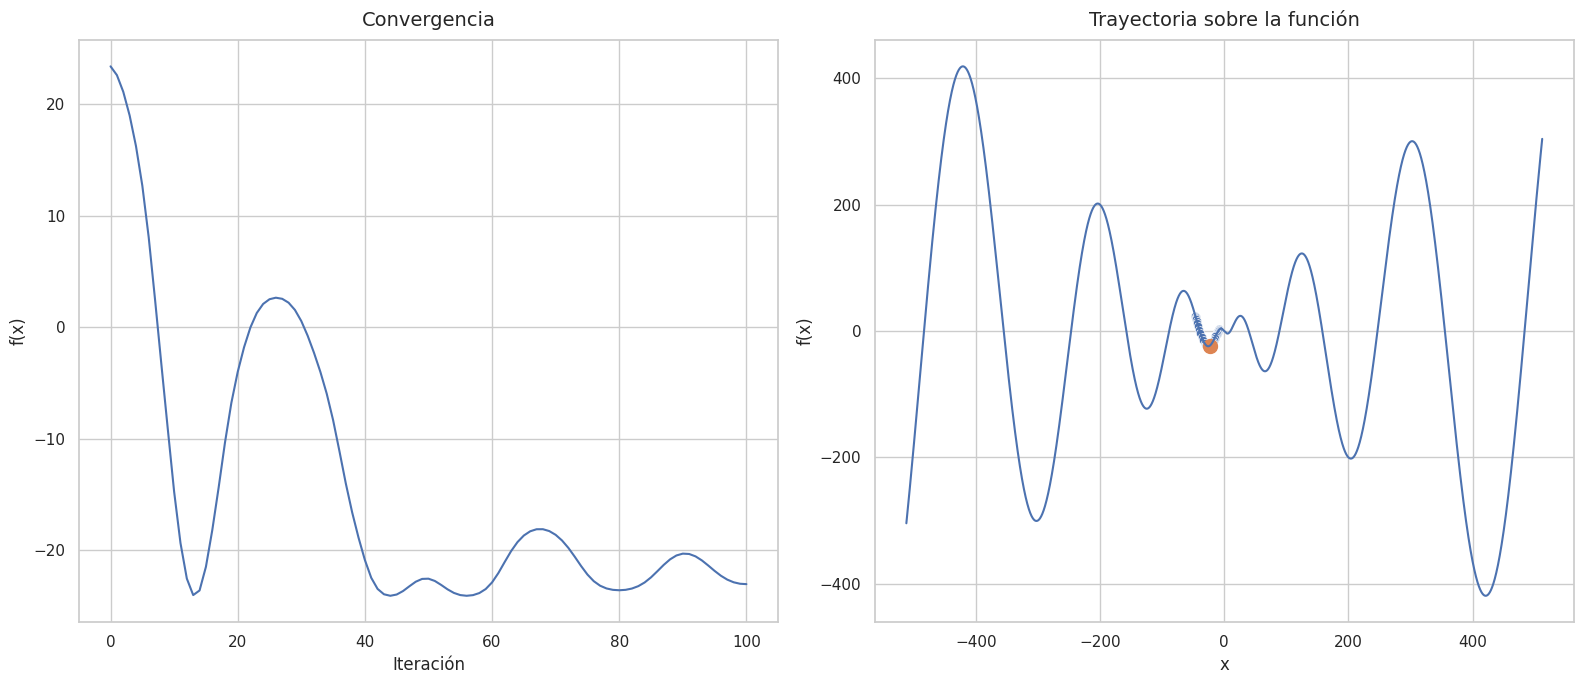


Mínimo final: x = -23.1524, f(x) = -23.0383


In [ ]:
make_animated_optimization_SGD(dom_f2, f_2, grad_f_2)

Esto no esta convergiendo!
Creemos que es por la naturaleza de la funcion.

In [ ]:
# funciones auxiliares
def make_experiment_SGD(function, grad_function, alphas, betas, k, inner, upper, epsilon=1e-6, max_iter=1000):
  """
  Funcion que lleva a cabo el experimento

  Resultados un diccionario de la forma:
    {
      alfa1: {
        beta1: {
          x: resultados de x
          y: resultados de y
          t: resultados de t,
          i: resultados de i
        }
        beta2: {
          x: resultados de x
        }
      }
      alfa2:{
        beta1:{
          x: resultados de x:
        }
      }
    }
  """


  dict_alphas = {}
  for alpha in alphas:
    dict_betas = {}
    for beta in betas:
      x = []
      y = []
      t = []
      i = []
      dict_results = {}

      for rep in range(k):
        optimizer = sgd(learning_rate=alpha, momentum=beta, inner_limit =inner, upper_limit = upper, max_iter = max_iter, epsilon = epsilon)
        start_time = time.time()
        x_opt = optimizer.optimize(function, grad_function)
        end_time = time.time()
        x.append(x_opt)
        y.append(function(x_opt))
        t.append(end_time - start_time)
        i.append(optimizer.iter)


      dict_results = {'x': x, 'y': y, 't': t, 'i': i}
      dict_betas[str(beta)] = dict_results
    dict_alphas[str(alpha)]=dict_betas

  return dict_alphas


def info_experiment_SGD(results, umbral,k=10):
  rows = []
  # construir el dataframe fila por fila
  for alfa, datos_alpha in results.items():
    for beta, datos_beta in datos_alpha.items():
      x = datos_beta["x"]
      y = datos_beta["y"]
      t = datos_beta["t"]
      i = datos_beta["i"]

      mean_x = np.mean(x)
      ic_x = 1.96 * np.std(x, ddof=1) / np.sqrt(len(x))

      mean_y = np.mean(y)
      ic_y = 1.96 * np.std(y, ddof=1) / np.sqrt(len(y))

      mean_t = np.mean(t)
      ic_t = 1.96 * np.std(t, ddof=1) / np.sqrt(len(t))

      mean_i = np.mean(i)
      ic_i = 1.96 * np.std(i, ddof=1) / np.sqrt(len(i))

      tasa_exito = (len(np.where(np.array(y) < umbral)[0])/k)*100

      row = {
          "alpha": alfa,
          "beta": beta,
          "x medio + IC": f"{mean_x:.7f} +- {ic_x:.7f}",
          "fitness media + IC": f"{mean_y:.7f} +- {ic_y:.7f}",
          "fitness mediana": np.median(y),
          "fitness mejor": np.min(y),
          "tiempo media + IC": f"{mean_t:.6f} +- {ic_t:.6f}",
          "evaluaciones media + IC": f"{mean_i:.6f} +- {ic_i:.6f}",
          "evaluaciones media": f"{mean_i:.6f}",
          "tasa de exito": tasa_exito
            }

      rows.append(row)

  df_sgd = pd.DataFrame(rows)
  return df_sgd


def mejor_configuracion_SGD(results):
  min_alpha =0
  min_beta = 0
  min_aux = np.inf
  for alpha in results:
    for beta in results[alpha]:
      current_idx = np.argmin(results[alpha][beta]['y'])
      if results[alpha][beta]['y'][current_idx] < min_aux:
        min_aux = results[alpha][beta]['y'][current_idx]
        min_alpha = alpha
        min_beta = beta
  return {'alpha': min_alpha, 'beta': min_beta}


### 2.3 Análisis de hiperparámetros en función convexa

La selección apropiada de $\alpha$ y $\beta$ es crucial para el desempeño de SGD. Esta sección explora sistemáticamente el espacio de hiperparámetros.

> Minimice $f_1(x) = (x-3)^2$ en $[-10, 10]$ explorando el siguiente grid de hiperparámetros:
> $$\alpha \in \{0.001, 0.01, 0.1, 0.5\}, \quad \beta \in \{0.0, 0.5, 0.9\}$$
> Esto resulta en $4 \times 3 = 12$ combinaciones. Para cada combinación:
> - Realice **10 repeticiones independientes** con inicializaciones aleatorias en $[-10, 10]$
> - Use los criterios de convergencia: $|x_t - x_{t-1}| < 10^{-6}$ o $T_{\max} = 1000$
> - Registre: mejor fitness alcanzado, tiempo de ejecución, **número de evaluaciones hasta convergencia**

> Para cada combinación $(\alpha, \beta)$, calcule media ± IC, mediana y mejor resultado para las tres métricas: fitness, tiempo y evaluaciones. Puede organizar los resultados en tablas separadas o en una tabla grande (12 filas × múltiples columnas). Considere el siguiente ejemplo de tabla:


| $\alpha$ | $\beta$ | Fitness: Media ± IC | Fitness: Mediana | Fitness: Mejor | Tiempo [s]: Media ± IC | Evaluaciones: Media ± IC |
|:--------:|:-------:|:------------------:|:----------------:|:--------------:|:----------------------:|:------------------------:|
| 0.001 | 0.0 | ... | ... | ... | ... | ... |
| 0.001 | 0.5 | ... | ... | ... | ... | ... |
| ... | ... | ... | ... | ... | ... | ... |

In [ ]:
alfas = [0.001, 0.01, 0.1, 0.5]
betas = [0.0, 0.5, 0.9]
n_repes = 10

results = make_experiment_SGD(
    function = f_1,
    grad_function = grad_f_1,
    alphas = alfas,
    betas = betas,
    k = n_repes,
    inner = dom_f1[0],
    upper = dom_f1[-1]
)
print(results)

df = info_experiment_SGD(results, 0.1)
df


aux_dict = mejor_configuracion_SGD(results)
best_experiments['SGD_cvx']= aux_dict.copy()

print(best_experiments)


{'0.001': {'0.0': {'x': [np.float64(2.9420098827666834), np.float64(3.2692906013242715), np.float64(2.9959586243415406), np.float64(2.872371202354935), np.float64(2.8852045823361516), np.float64(1.7899621622467587), np.float64(3.3613897431484845), np.float64(1.3433435606687671), np.float64(1.4932760148624733), np.float64(3.1714211270802215)], 'y': [np.float64(0.0033628536967338024), np.float64(0.07251742796158775), np.float64(1.6332717212788246e-05), np.float64(0.016289109988324998), np.float64(0.013177987916617392), np.float64(1.4641915687945395), np.float64(0.1306025464529276), np.float64(2.7445105579776388), np.float64(2.2702171673887097), np.float64(0.02938520280945345)], 't': [0.0077517032623291016, 0.008129596710205078, 0.008057355880737305, 0.00810861587524414, 0.007025241851806641, 0.006890535354614258, 0.012440204620361328, 0.01768970489501953, 0.010000944137573242, 0.007315635681152344], 'i': [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]}, '0.5': {'x': [np.floa

> Además, genere las siguientes visualizaciones:
> 1. **Heatmap de fitness**, mostrando el fitness promedio final para cada combinación $(\alpha, \beta)$. Use una escala de color donde tonos más oscuros indiquen mejor desempeño (menor fitness).
> 2. **Heatmap de tiempo**, mostrando tiempo promedio de ejecución. Identifique combinaciones que convergen rápidamente.


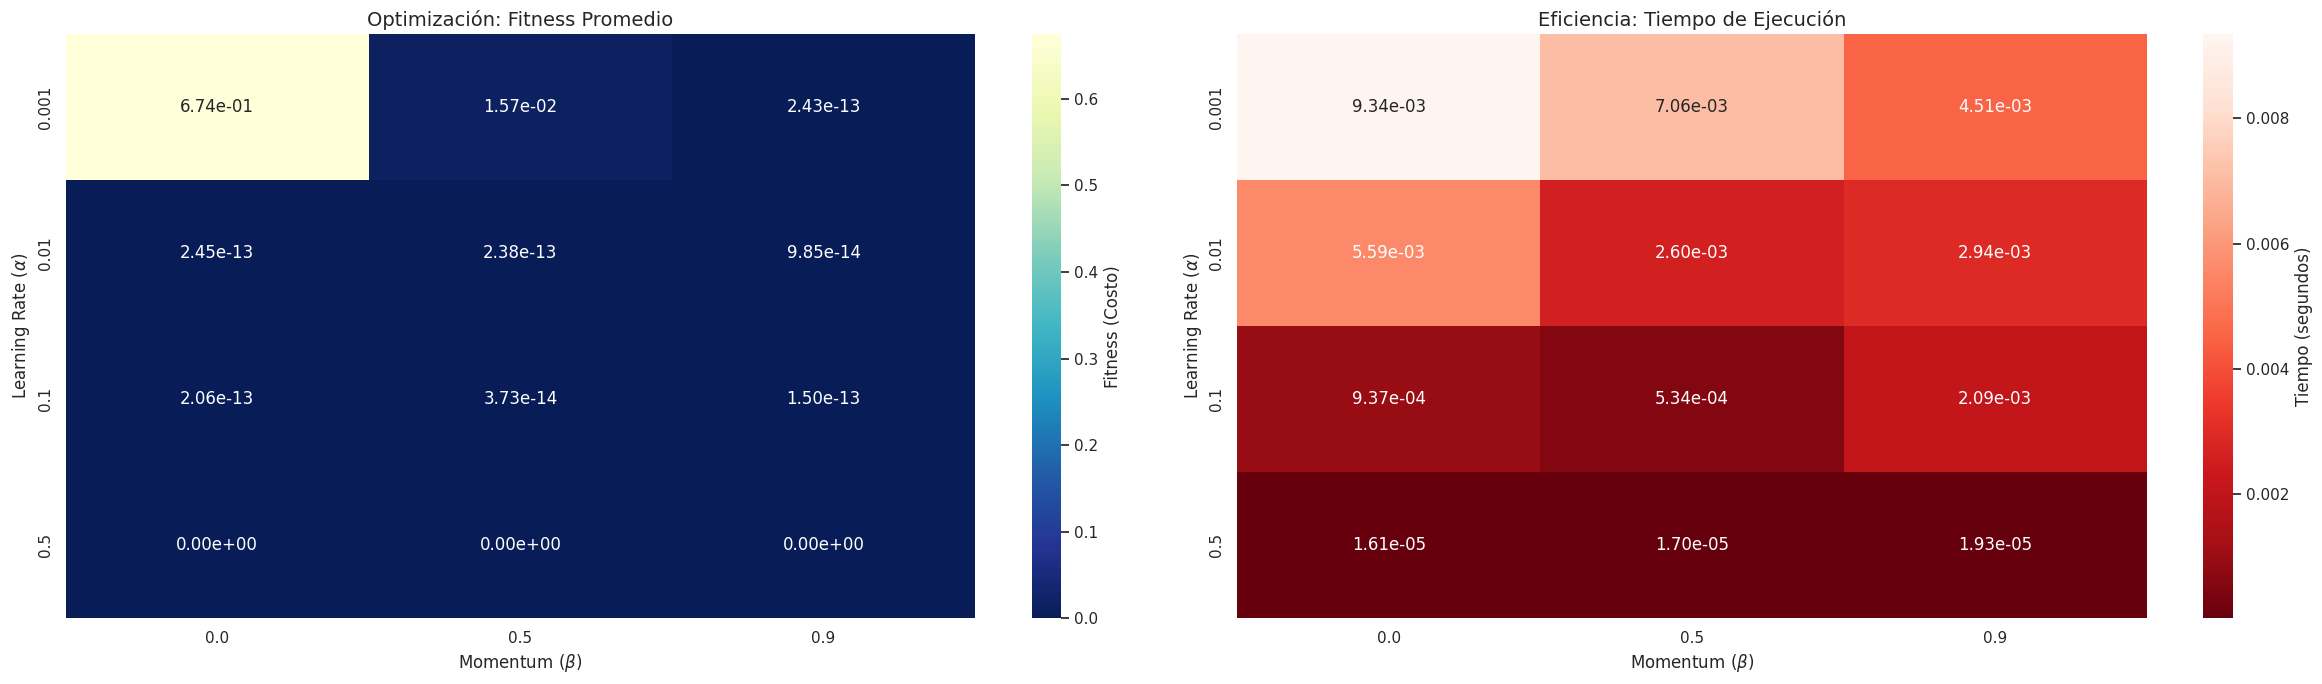

In [ ]:
filas_planas = []
for alpha, niveles_beta in results.items():
    for beta, datos in niveles_beta.items():
        filas_planas.append({
            'LR_Alpha': float(alpha),
            'Momentum_Beta': float(beta),
            'Fitness_Promedio': np.mean(datos['y']),
            'Tiempo_Promedio': np.mean(datos['t'])
        })

df_grid = pd.DataFrame(filas_planas)


fitness_heatmap = df_grid.pivot(index='LR_Alpha', columns='Momentum_Beta', values='Fitness_Promedio')
tiempo_heatmap = df_grid.pivot(index='LR_Alpha', columns='Momentum_Beta', values='Tiempo_Promedio')

fig, axs = plt.subplots(1, 2, figsize=(24, 7))
sns.set_theme()

sns.heatmap(
    fitness_heatmap,
    annot=True, fmt=".2e", cmap="YlGnBu_r", ax=axs[0],
    cbar_kws={'label': 'Fitness (Costo)'}
)
axs[0].set_title('Optimización: Fitness Promedio', fontsize=14)
axs[0].set_xlabel('Momentum ($\\beta$)')
axs[0].set_ylabel('Learning Rate ($\\alpha$)')

sns.heatmap(
    tiempo_heatmap,
    annot=True, fmt=".2e", cmap="Reds_r", ax=axs[1],
    cbar_kws={'label': 'Tiempo (segundos)'}
)
axs[1].set_title('Eficiencia: Tiempo de Ejecución', fontsize=14)
axs[1].set_xlabel('Momentum ($\\beta$)')
axs[1].set_ylabel('Learning Rate ($\\alpha$)')


plt.tight_layout()
plt.show()

Un grafico un poco mas explicativo


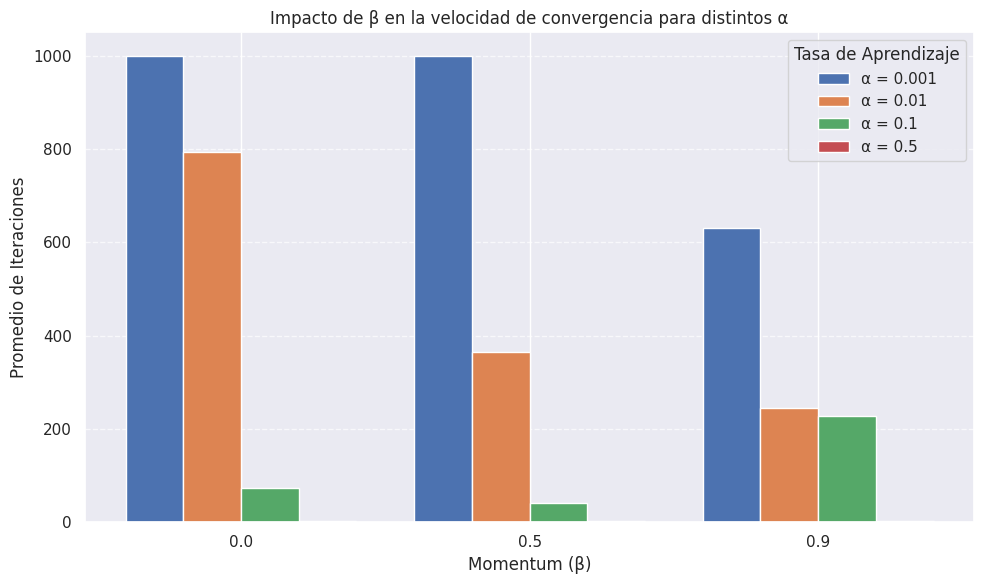

In [ ]:
labels_beta = [str(b) for b in betas]
x = np.arange(len(labels_beta))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

# Iteramos sobre cada alfa
for i, alfa in enumerate(alfas):
    promedios_iter = []

    for beta in betas:
        datos_repeticiones = results[str(alfa)][str(beta)]['i']
        promedios_iter.append(np.mean(datos_repeticiones))

    offset = (i - len(alfas)/2) * width + width/2
    ax.bar(x + offset, promedios_iter, width, label=f'α = {alfa}')

# Estética
ax.set_xlabel('Momentum (β)')
ax.set_ylabel('Promedio de Iteraciones')
ax.set_title('Impacto de β en la velocidad de convergencia para distintos α')
ax.set_xticks(x)
ax.set_xticklabels(labels_beta)
ax.legend(title="Tasa de Aprendizaje")
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Podemos ver que la tendencia es:
- Beta grande, el modelo es mas general, poco desvio en las iteraciones promedios, implica mejores resultados.
- Beta pequeño: se obtuvieron mejores resultados especificamente
- Alfa: El modelo tiende a mejorar cuando este disminuye y el momento es pequeño. Cuando el momento es grande, funciona "mejor" reducir el alfa.

Es un balance entre ambos.

______________________________
**Preguntas de análisis**:

1. ¿Qué combinación $(\alpha, \beta)$ proporciona el mejor desempeño en términos de fitness final?
2. ¿Qué combinación converge más rápidamente (menor tiempo o evaluaciones)?
3. ¿Existe un trade-off entre velocidad de convergencia y calidad de solución?
4. ¿Cómo afecta el momento ($\beta$) para diferentes valores de $\alpha$? ¿Es consistente el efecto?
5. ¿Alguna combinación falla en converger dentro de $T_{\max}$ iteraciones? ¿Por qué?
6. Dado que $f_1$ es convexa, ¿todas las combinaciones alcanzan el óptimo global eventualmente?


**Algunas respuestas**

El mejor desempeño fue beta 0 y alfa 0.5 (Converge en 2 pasos, en promedio) pero por coincidencia matematica y particularidad del problema.

Hay combinaciones que han de necesitar 1000 iteraciones para converger, como por ejemplo aquellas que tienen un alfa mu pequeño y beta tambien pequeño. Se entiende como que el desenso tiene poco movimiento y demanda de mas operaciones.

Se alcanza el optimo global si es estrictamente convexa (como lo es en este caso)



### 2.4 Análisis de hiperparámetros en función no convexa

Ahora evaluamos SGD en el desafiante paisaje multimodal de la función de Schwefel.


> Minimice $f_2(x)$ usando el mismo grid de hiperparámetros:
> $$\alpha \in \{0.001, 0.01, 0.1, 0.5\}, \quad \beta \in \{0.0, 0.5, 0.9\}$$
> Realice **10 repeticiones** por combinación con inicializaciones aleatorias en el dominio completo. Registre las mismas métricas que en 2.3, más la tasa de éxito ($f(x^*) < -400$).
> Complete tablas análogas a las de la sección 2.3, pero ahora incluyendo la columna de tasa de éxito.

> Además, genere las siguientes visualizaciones:
> 1. **Heatmap de fitness promedio**, similar a 2.3 (los valores mostrarán mayor dispersión debido a la multimodalidad).
> 2. **Heatmap de tasa de éxito**, mostrando el porcentaje de ejecuciones exitosas ($f < -400$) para cada combinación. Este gráfico revela qué configuraciones son más robustas ante inicializaciones aleatorias.
> 3. **Heatmap de evaluaciones promedio**, mostrando el número promedio de evaluaciones hasta convergencia. Observe si las configuraciones que convergen rápido también encuentran buenas soluciones.
> 4. **Curvas de convergencia** para cada valor de $\beta$ (ej., $\beta=0.5$), superponiendo las curvas típicas de convergencia (fitness vs iteraciones) para los cuatro valores de $\alpha$. Use una ejecución representativa para cdaa caso.

**Preguntas de análisis**:

1. ¿Los hiperparámetros óptimos para $f_1$ siguen siendo óptimos para $f_2$? Si no, ¿qué cambió?
2. ¿Qué combinaciones logran altas tasas de éxito? ¿Existe un patrón común?
3. ¿Hay combinaciones que sistemáticamente quedan atrapadas en óptimos locales? ¿Cuáles y por qué?
4. ¿Cómo afecta el momento ($\beta$) la capacidad de escapar de óptimos locales?
5. ¿Valores grandes de $\alpha$ ayudan a explorar más el espacio, o simplemente causan inestabilidad?
6. Compare la variabilidad (dispersión en boxplots) entre $f_1$ y $f_2$. ¿Por qué es mayor en $f_2$?
7. ¿El número de evaluaciones hasta convergencia es un buen indicador de la calidad final de la solución?

---

In [ ]:
alfas = [0.001, 0.01, 0.1, 0.5]
betas = [0.0, 0.5, 0.9]
n_repes = 100

results = make_experiment_SGD(
    function = f_2,
    grad_function = grad_f_2,
    alphas = alfas,
    betas = betas,
    k = n_repes,
    inner = dom_f2[0],
    upper = dom_f2[-1],
)


aux_dict = mejor_configuracion_SGD(results)
best_experiments['SGD_non_cvx']= aux_dict.copy()
print(best_experiments)

df = info_experiment_SGD(results, -400, k=n_repes)
df


{'RS_cvx': {'N': '500'}, 'RS_non_cvx': {'N': '500'}, 'SGD_cvx': {'alpha': '0.5', 'beta': '0.0'}, 'SGD_non_cvx': {'alpha': '0.01', 'beta': '0.0'}}


,alpha,beta,x medio + IC,fitness media + IC,fitness mediana,fitness mejor,tiempo media + IC,evaluaciones media + IC,evaluaciones media,tasa de exito
0,0.001,0.0,4.1922629 +- 56.8946522,-44.5480946 +- 35.9343571,-26.319356,-418.885615,0.033149 +- 0.001843,1000.000000 +- 0.000000,1000.000000,3.0
1,0.001,0.5,-27.6766201 +- 59.1717237,-86.9302951 +- 37.8859847,-78.131395,-418.615716,0.023278 +- 0.000575,1000.000000 +- 0.000000,1000.000000,3.0
2,0.001,0.9,23.5817161 +- 60.2384257,-195.8993752 +- 36.9318961,-201.798335,-418.915204,0.022795 +- 0.000516,1000.000000 +- 0.000000,1000.000000,22.0
3,0.01,0.0,-13.9855556 +- 59.4389453,-186.7177600 +- 31.7179465,-198.003940,-418.980866,0.022752 +- 0.000546,1000.000000 +- 0.000000,1000.000000,15.0
4,0.01,0.5,58.1744140 +- 58.9287527,-239.4631433 +- 26.3954833,-201.799137,-417.608385,0.021690 +- 0.000542,977.040000 +- 13.218367,977.040000,26.0
5,0.01,0.9,-49.5135775 +- 59.7548081,-239.3670047 +- 25.4730619,-298.471279,-417.606411,0.016822 +- 0.001768,416.830000 +- 43.752248,416.830000,17.0
6,0.1,0.0,16.0044263 +- 57.2567055,-224.1921504 +- 30.5209084,-298.471279,-417.606411,0.012832 +- 0.001689,316.970000 +- 37.356900,316.970000,23.0
7,0.1,0.5,-15.5322389 +- 55.9067090,-204.7030347 +- 27.7917402,-201.796479,-417.606411,0.005054 +- 0.001370,213.170000 +- 55.095700,213.170000,17.0
8,0.1,0.9,-4.5901743 +- 59.2847922,-237.6354062 +- 26.9905135,-298.471279,-417.606411,0.007530 +- 0.001070,325.070000 +- 42.528713,325.070000,23.0
9,0.5,0.0,-53.1967458 +- 56.9195804,-225.4945893 +- 25.3975596,-250.133879,-417.606411,0.003615 +- 0.001383,153.050000 +- 58.729354,153.050000,14.0


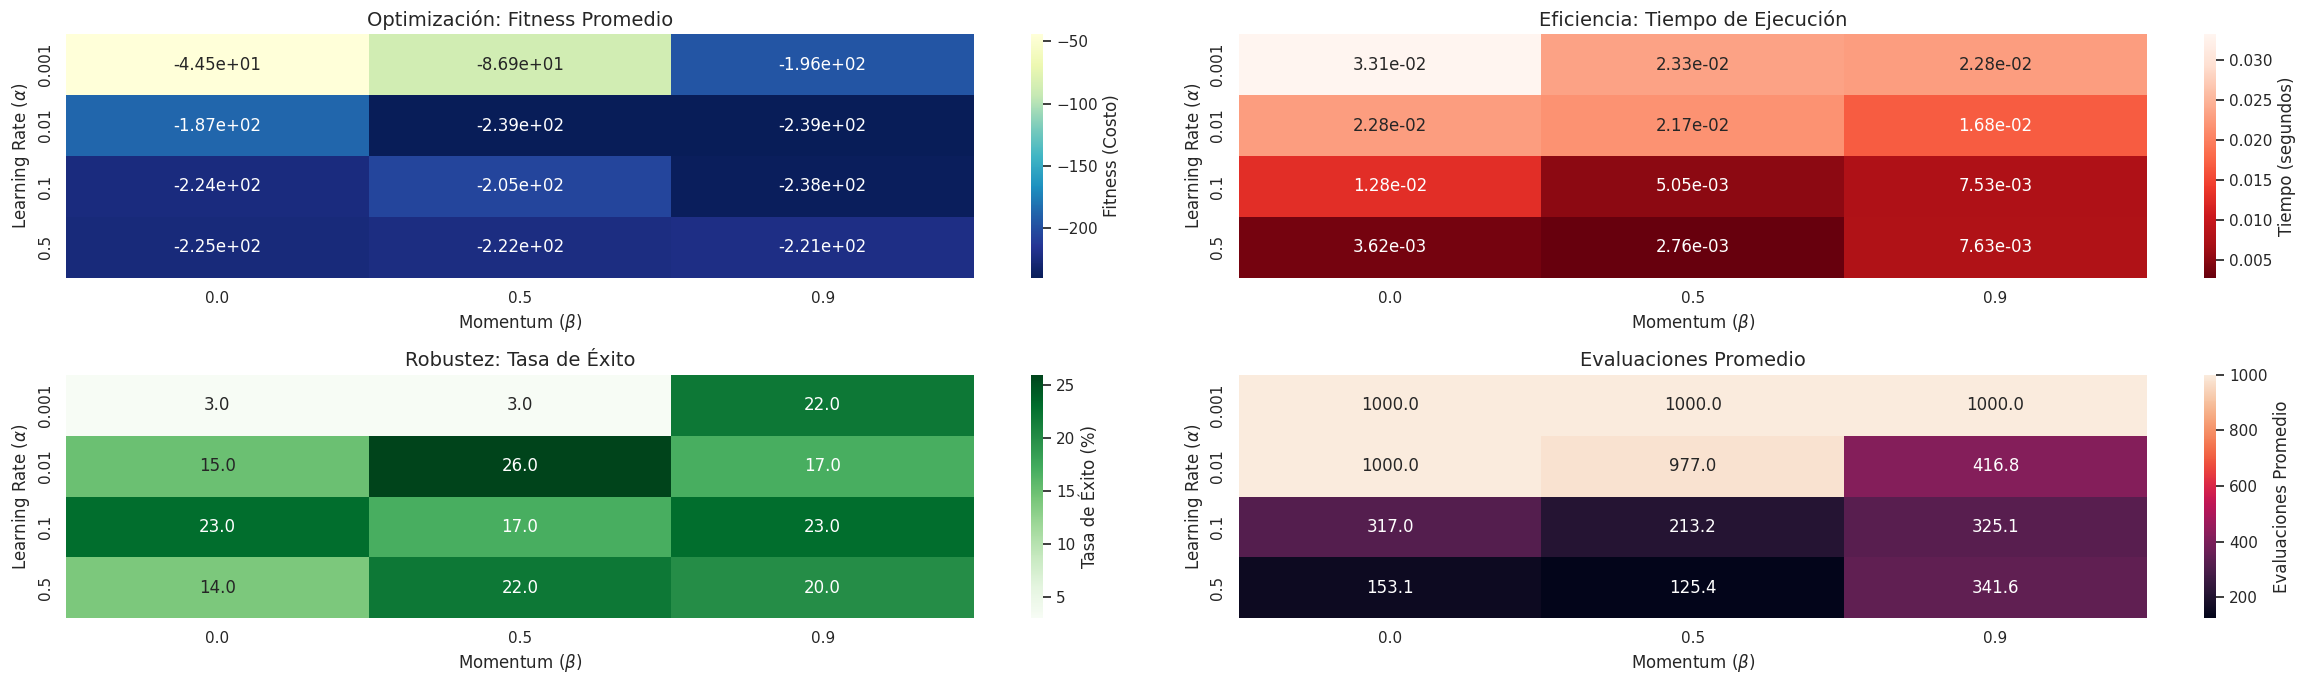

In [ ]:
filas_planas = []
for alpha, niveles_beta in results.items():
    for beta, datos in niveles_beta.items():
        filas_planas.append({
            'LR_Alpha': float(alpha),
            'Momentum_Beta': float(beta),
            'Fitness_Promedio': np.mean(datos['y']),
            'Tiempo_Promedio': np.mean(datos['t'])
        })

df_grid = pd.DataFrame(filas_planas)


fitness_heatmap = df_grid.pivot(index='LR_Alpha', columns='Momentum_Beta', values='Fitness_Promedio')
tiempo_heatmap = df_grid.pivot(index='LR_Alpha', columns='Momentum_Beta', values='Tiempo_Promedio')
tasa_exito_heatmap = df.pivot(index='alpha', columns='beta', values='tasa de exito')
evaluaciones_media_heatmap = df.pivot(index='alpha', columns='beta', values='evaluaciones media')
evaluaciones_media_heatmap = evaluaciones_media_heatmap.astype(float)

fig, axs = plt.subplots(2,2, figsize=(24, 7))
axs = axs.flatten()
sns.set_theme()

sns.heatmap(
    fitness_heatmap,
    annot=True, fmt=".2e", cmap="YlGnBu_r", ax=axs[0],
    cbar_kws={'label': 'Fitness (Costo)'}
)
axs[0].set_title('Optimización: Fitness Promedio', fontsize=14)
axs[0].set_xlabel('Momentum ($\\beta$)')
axs[0].set_ylabel('Learning Rate ($\\alpha$)')

sns.heatmap(
    tiempo_heatmap,
    annot=True, fmt=".2e", cmap="Reds_r", ax=axs[1],
    cbar_kws={'label': 'Tiempo (segundos)'}
)
axs[1].set_title('Eficiencia: Tiempo de Ejecución', fontsize=14)
axs[1].set_xlabel('Momentum ($\\beta$)')
axs[1].set_ylabel('Learning Rate ($\\alpha$)')

sns.heatmap(
    tasa_exito_heatmap,
    annot=True, fmt=".1f", cmap="Greens", ax=axs[2],
    cbar_kws={'label': 'Tasa de Éxito (%)'}
)
axs[2].set_title('Robustez: Tasa de Éxito', fontsize=14)
axs[2].set_xlabel('Momentum ($\\beta$)')
axs[2].set_ylabel('Learning Rate ($\\alpha$)')


sns.heatmap(
    evaluaciones_media_heatmap,
    annot=True, fmt=".1f", ax=axs[3],
    cbar_kws={'label': 'Evaluaciones Promedio'}
)
axs[3].set_title('Evaluaciones Promedio', fontsize=14)
axs[3].set_xlabel('Momentum ($\\beta$)')
axs[3].set_ylabel('Learning Rate ($\\alpha$)')



plt.tight_layout()
plt.show()

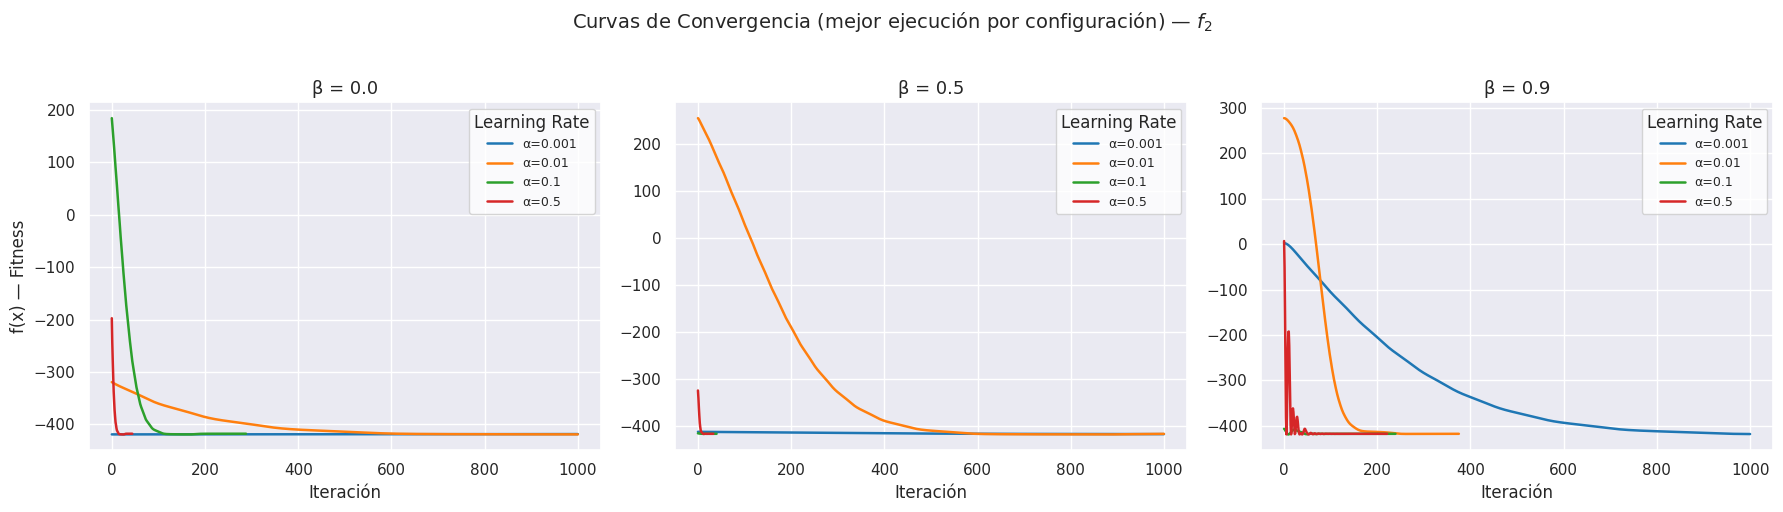

In [ ]:
# Curvas de convergencia: para cada beta, superponer las curvas de los 4 alphas
# Ejecución representativa = la mejor de las n_repes repeticiones (menor fitness final)


alfas = [0.001, 0.01, 0.1, 0.5]
betas = [0.0, 0.5, 0.9]
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axs = plt.subplots(1, len(betas), figsize=(18, 5), sharey=False)
sns.set_theme(style='whitegrid')

for j, beta in enumerate(betas):
    ax = axs[j]
    for i, alpha in enumerate(alfas):
        # Repetir n_repes veces y quedarse con la historia de la mejor corrida
        best_fitness = np.inf
        best_hist_f = None
        for _ in range(n_repes):
            opt = sgd(
                learning_rate=alpha,
                momentum=beta,
                epsilon=1e-6,
                max_iter=1000,
                inner_limit=dom_f2[0],
                upper_limit=dom_f2[-1]
            )
            opt.optimize(f_2, grad_f_2)
            if opt.hist_f[-1] < best_fitness:
                best_fitness = opt.hist_f[-1]
                best_hist_f = list(opt.hist_f)

        ax.plot(range(len(best_hist_f)), best_hist_f, color=colores[i], label=f'α={alpha}', linewidth=1.8)

    ax.set_title(f'β = {beta}', fontsize=13)
    ax.set_xlabel('Iteración')
    if j == 0:
        ax.set_ylabel('f(x) — Fitness')
    ax.legend(title='Learning Rate', fontsize=9)

fig.suptitle('Curvas de Convergencia (mejor ejecución por configuración) — $f_2$', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

podemos ver en X que converge a cualquier cosa, muchiiiiiismo ruido en las respuestas!!

mmmmmfffffghhh

## Sección 3: *Hill Climbing*

*Hill Climbing* es un algoritmo de búsqueda local que explora iterativamente el vecindario de la solución actual y se mueve a la mejor solución vecina si esta mejora el fitness. A diferencia de SGD, no requiere cálculo de gradientes, pero comparte con él el carácter puramente local de la búsqueda, lo que lo hace vulnerable a óptimos locales.

### 3.1 Fundamentos del algoritmo


*Hill Climbing* es la versión más simple de búsqueda local. En cada iteración, el algoritmo evalúa vecinos de la solución actual y se mueve al primero que encuentre con mejor fitness (*first improvement*) o al mejor de todos los vecinos evaluados (*best improvement*). Aquí implementaremos la variante de best *improvement* con vecindario determinado por un parámetro $\delta$ que define el tamaño del paso de exploración.

Para problemas unidimensionales, el vecindario de $x$ está dado por:

$$\mathcal{N}(x) = \{x - \delta, x + \delta\}$$

El algoritmo converge cuando ningún vecino mejora el fitness actual, indicando que se alcanzó un óptimo local.

$$
\begin{array}{ll}
\hline
\textbf{Algoritmo 3:} & \textbf{Hill Climbing} \\
\hline
\textbf{Entrada:} & \text{Punto inicial } x_0, \text{ tamaño de paso } \delta, \text{ máximo de iteraciones } T_{\max} \\
\textbf{Salida:} & \text{Solución } x^* \text{ y su fitness } f(x^*) \\
\hline
\end{array}
$$

$$
\begin{array}{ll}
1: & x \leftarrow x_0 \\
2: & \text{mejorado} \leftarrow \text{True} \\
3: & t \leftarrow 0 \\
4: & \textbf{while } \text{mejorado} \textbf{ and } t < T_{\max} \textbf{ do} \\
5: & \quad \text{mejorado} \leftarrow \text{False} \\
6: & \quad \text{vecinos} \leftarrow \{x - \delta, x + \delta\} \\
7: & \quad \textbf{foreach } x_{\text{vecino}} \in \text{vecinos} \textbf{ do} \\
8: & \quad \quad \textbf{if } f(x_{\text{vecino}}) < f(x): \\
9: & \quad \quad \quad x \leftarrow x_{\text{vecino}} \\
10: & \quad \quad \quad \text{mejorado} \leftarrow \text{True} \\
12: & \quad \quad \textbf{end if} \\
13: & \quad \textbf{end foreach} \\
14: & \quad t \leftarrow t + 1 \\
15: & \textbf{end while} \\
16: & \textbf{return } (x, f(x))
\end{array}
$$

**Hiperparámetro**:

- **$\delta$ (tamaño de paso)**: Controla el tamaño del vecindario explorado. Valores grandes permiten saltos amplios pero pueden "saltar sobre" el óptimo. Valores pequeños refinan la búsqueda pero requieren más iteraciones. La elección de $\delta$ debe considerar la escala del problema y la rugosidad del paisaje de fitness.

**Criterios de convergencia**:
- No hay mejora en el vecindario: $|f_{\text{mejor}} - f_{\text{actual}}| < \varepsilon = 10^{-6}$
- Número máximo de iteraciones: $T_{\max} = 1000$


In [ ]:

class hill_climbing ():
  def __init__(self, delta, lower_limit, upper_limit,partition_size =1000, T_max  =3000):
    self.t_max = T_max
    self.delta = delta
    self.lower = lower_limit
    self.upper= upper_limit
    self.partition = partition_size if partition_size % 2 != 0 else partition_size + 1
    self.t = 0

  def optimize(self, function):
    dom = np.linspace(self.lower, self.upper, self.partition)
    x_0 = np.random.choice(dom)
    current_min = x_0

    for t in range(self.t_max):

        vecindario_min = max(current_min - self.delta, self.lower)
        vecindario_max = min(current_min + self.delta, self.upper)

        if vecindario_min >= vecindario_max:
          self.t = t
          return current_min, function(current_min)
        vecindad = np.linspace(vecindario_min,vecindario_max, self.partition)
        index = np.argmin(function(vecindad))
        if np.abs(vecindad[index]- current_min) <1e-10:
          self.t=t
          return current_min, function(current_min)

        if np.abs(function(current_min) - function(vecindad[index]))<1e-6:
          self.t = t
          return current_min, function(current_min) #si no cambio mucho devuelvo (sin cambiar)

        current_min = vecindad[index] #actualizo si no entro a los ifs anterior y salto a la siguiente iteracion
    self.t = self.t_max
    return current_min, function(current_min)



def make_animated_optimization_HC(dominio, function, delta, lower, upper, partition_size=1000, t_max=50):
    """
    Visualización iterativa manual del proceso de Hill Climbing paso a paso.
    """
    # --- Inicialización del algoritmo ---
    dom_discreto = np.linspace(lower, upper, partition_size)
    current_x = np.random.choice(dom_discreto)

    historial_t = []
    historial_f = []
    historial_x = []

    y_funcion = function(dominio)

    # --- Bucle de Optimización y Dibujo ---
    for t in range(t_max):
        # 1. Lógica de optimización (un paso de Hill Climbing)
        curr_f = function(current_x)

        # Definir vecindad según el delta
        v_min = max(current_x - delta, lower)
        v_max = min(current_x + delta, upper)

        vecindad = np.linspace(v_min, v_max, partition_size)
        f_vecindad = function(vecindad)

        # Encontrar el mejor vecino
        idx_mejor = np.argmin(f_vecindad)
        next_x = vecindad[idx_mejor]
        next_f = f_vecindad[idx_mejor]

        # Guardar datos para los gráficos
        historial_t.append(t)
        historial_f.append(curr_f)
        historial_x.append(current_x)

        # 2. Proceso de Visualización
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # --- AX 0: Evolución del Fitness ---
        axes[0].set_title(f"Evolución del Fitness (t={t})", fontsize=14)
        sns.lineplot(x=historial_t, y=historial_f, ax=axes[0], color='blue', marker='o')
        axes[0].set_xlabel("Iteración (t)")
        axes[0].set_ylabel("f(x)")
        axes[0].grid(True, alpha=0.3)

        # --- AX 1: Función y estado actual ---
        axes[1].set_title("Movimiento en el Dominio", fontsize=14)
        # Dibujamos la función de fondo
        axes[1].plot(dominio, y_funcion, color='black', alpha=0.2, label='f(x)')

        # Dibujamos la vecindad actual (área de búsqueda)
        axes[1].axvspan(v_min, v_max, color='yellow', alpha=0.3, label='Vecindad ($\Delta$)')

        # Dibujamos el historial de puntos visitados y el actual
        axes[1].scatter(historial_x[:-1], historial_f[:-1], color='gray', s=20, alpha=0.5)
        axes[1].scatter(current_x, curr_f, color='red', s=100, edgecolors='black', label='Actual', zorder=5)

        axes[1].set_xlabel("x")
        axes[1].set_ylabel("f(x)")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        # 3. Criterios de parada
        if np.abs(next_x - current_x) < 1e-10 or np.abs(curr_f - next_f) < 1e-6:
            print(f"Convergencia alcanzada en t={t}. Mínimo en x={current_x:.4f}, f(x)={curr_f:.4f}")
            break

        current_x = next_x

    return current_x, function(current_x)



<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:92: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_990/3113252596.py:92: SyntaxWarning: invalid escape sequence '\D'
  axes[1].axvspan(v_min, v_max, color='yellow', alpha=0.3, label='Vecindad ($\Delta$)')


In [ ]:

def make_experiment_HC(function, deltas, k, lower, upper):

  """
  Retorna:
  delta:{
    x: x_results,
    y: y_results,
    t: t_results,
    t_max?
  }
  """

  dict_results_hill = {}
  for delta in deltas:
    inner_dict = {}
    current_x=[]
    current_y = []
    current_t = []
    current_t_max = []
    opt_delta = hill_climbing(delta, lower, upper)
    for n in range(n_rep):
      start_time = time.time()
      min_x, fit = opt_delta.optimize(function)
      end_time = time.time()
      current_x.append(min_x)
      current_y.append(fit)
      current_t.append(end_time - start_time)
      current_t_max.append(opt_delta.t)

    inner_dict = {'x': current_x, 'y': current_y, 't':current_t, 't_max': current_t_max}
    dict_results_hill[str(delta)]= inner_dict

  return dict_results_hill


def info_experiment_HC(results, umbral):
  rows = []
  for delta, current_delta in results.items():
    tasa_exito = (len(np.where(np.array(current_delta['y']) < umbral)[0])/10)*100

    row = {
        'Delta': delta,
        'x media + IC': f"{np.mean(current_delta['x'])} +- {1.96*np.std(current_delta['x']/np.sqrt(n_rep))}",
        'Fitness: media + IC': f"{np.mean(current_delta['y'])} +- {1.96*np.std(current_delta['y']/np.sqrt(n_rep))}",
        'Fitness: mediana': np.median(current_delta['y']),
        'Tiempo: media + IC': f"{np.mean(current_delta['t'])} +- {1.96*np.std(current_delta['t']/np.sqrt(n_rep))}",
        'Evaluaciones_Media + IC': f"{np.mean(current_delta['t_max'])} +- {1.96*np.std(current_delta['t_max']/np.sqrt(n_rep))}",
        'tasa de exito': tasa_exito

    }
    rows.append(row)


  df= pd.DataFrame(rows)

  return df






### 3.2 Implementación con visualización en tiempo real

> Adapte la visualización de secciones anteriores para *Hill Climbing*.
> **Requisitos de visualización**:
> - **Panel izquierdo**: Evolución del fitness de la solución actual a lo largo de las iteraciones
> - **Panel derecho**: Posición actual sobre la función objetivo.

> Ejecute el algoritmo para $f_1$ con $\delta=1.0$ y una inicialización aleatoria en $[-10, 10]$. Observe cómo la solución se mueve consistentemente "cuesta abajo". Repita con inicializaciones en diferentes regiones para ver si siempre converge al mismo punto.

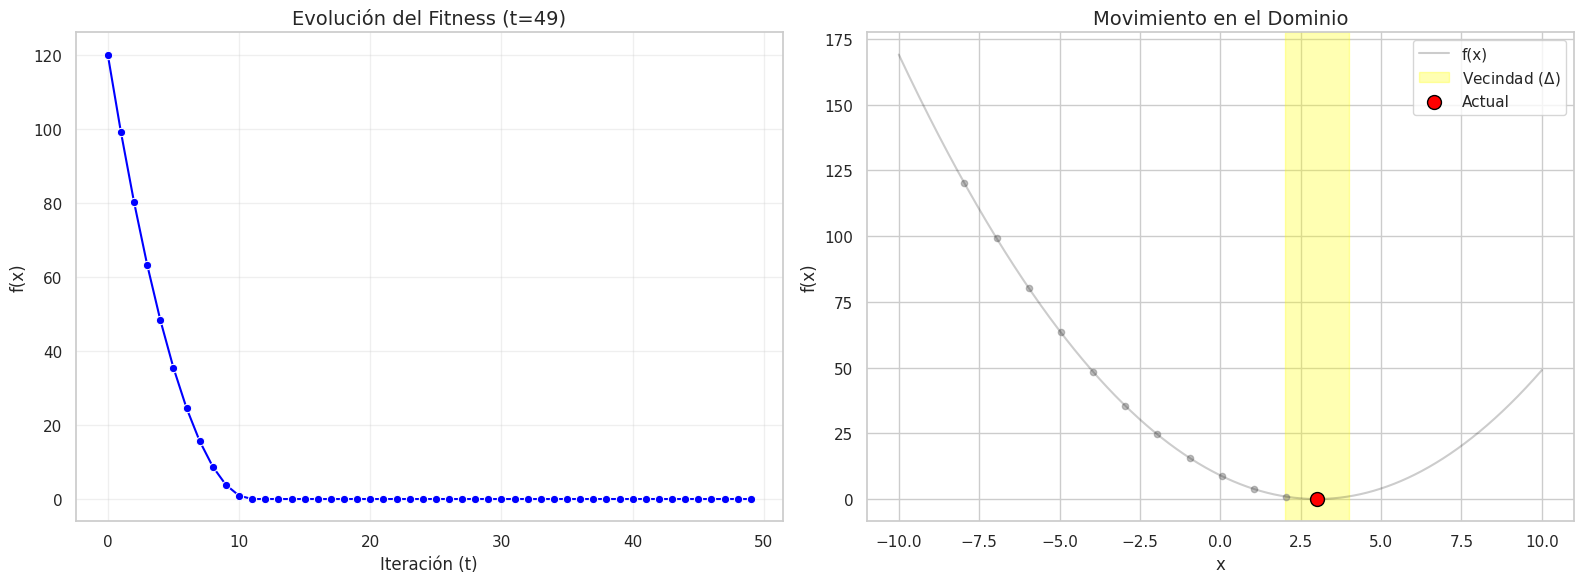

(np.float64(2.998998998998999), np.float64(1.0020030040051832e-06))

In [ ]:
make_animated_optimization_HC(dom_f1, f_1, 1, -10, 10)

### 3.3 Análisis de hiperparámetros en función convexa


Exploramos el efecto del tamaño de paso $\delta$ en el desempeño de Hill Climbing sobre la función convexa.

> Minimice $f_1(x) = (x-3)^2$ en $[-10, 10]$ explorando los siguientes valores del hiperparámetro:
> $$\delta \in \{0.1, 0.5, 1.0, 5.0\}$$
> Para cada valor de $\delta$:
> - Realice **10 repeticiones independientes** con inicializaciones aleatorias en $[-10, 10]$
> - Use los criterios de convergencia: $|f_{\text{mejor}} - f_{\text{actual}}| < 10^{-6}$ o $T_{\max} = 1000$
> - Registre: mejor fitness alcanzado, tiempo de ejecución, **número de evaluaciones hasta convergencia**


> Para cada valor de $\delta$, calcule media ± IC, mediana y mejor resultado para fitness, tiempo y evaluaciones.

| $\delta$ | Fitness: Media ± IC | Fitness: Mediana | Fitness: Mejor | Tiempo [s]: Media ± IC | Evaluaciones: Media ± IC |
|:--------:|:------------------:|:----------------:|:--------------:|:----------------------:|:------------------------:|
| 0.1 | ... | ... | ... | ... | ... |
| 0.5 | ... | ... | ... | ... | ... |
| 1.0 | ... | ... | ... | ... | ... |
| 5.0 | ... | ... | ... | ... | ... |

> Además, genere las siguientes visualizaciones:
> 1. **Boxplot** con la distribución del fitness final para cada valor de $\delta$. En una función convexa, esperamos que todos los valores alcancen el óptimo, pero pueden diferir en rapidez.
> 2. **Gráfico de barras** mostrando el número promedio de evaluaciones vs $\delta$. ¿Valores mayores de $\delta$ reducen el número de iteraciones?


In [ ]:
def buscar_mejor_HC(results):
  n_min = 0
  min = np.inf
  for n in results:
    idx_min = np.argmin(results[n]['y'])
    curr_fit = results[n]['y'][idx_min]
    if curr_fit <min:
      min = curr_fit
      n_min = n

  return {'delta': n_min}


In [ ]:
deltas= [0.1, 0.5, 1.0, 5.0]
n_rep = 10


results = make_experiment_HC(f_1, deltas, n_rep, -10, 10)

best_experiments ['HC_cvx'] = buscar_mejor_HC(results)
print(best_experiments)
df=info_experiment_HC(results, 0.1)
df




{'RS_cvx': {'N': '500'}, 'RS_non_cvx': {'N': '500'}, 'SGD_cvx': {'alpha': '0.5', 'beta': '0.0'}, 'SGD_non_cvx': {'alpha': '0.01', 'beta': '0.0'}, 'HC_cvx': {'delta': '0.5'}}


,Delta,x media + IC,Fitness: media + IC,Fitness: mediana,Tiempo: media + IC,Evaluaciones_Media + IC,tasa de exito
0,0.1,2.9999999999999973 +- 4.738567549521651e-15,6.581072101806291e-29 +- 4.7025100624108067e-29,3.914722e-29,0.0022518396377563476 +- 0.0009208290396040846,67.3 +- 26.353145724941452,100.0
1,0.5,3.0000000000000004 +- 3.9529677491530466e-16,4.733165431326071e-31 +- 5.712455509306293e-31,1.972152e-31,0.00040645599365234374 +- 0.00014531424245203041,12.9 +- 4.876029368246257,100.0
2,1.0,3.0 +- 4.241877275174126e-16,4.733165431326071e-31 +- 4.276487653547592e-31,9.860761e-32,0.0002153158187866211 +- 4.505466476525781e-05,6.1 +- 1.2534809132970473,100.0
3,5.0,3.0002560000000003 +- 0.0004760113316299414,6.553600000004013e-07 +- 1.2185890089731003e-06,0.000000e+00,9.822845458984375e-05 +- 1.4515376929808813e-05,1.7 +- 0.484084290180956,100.0


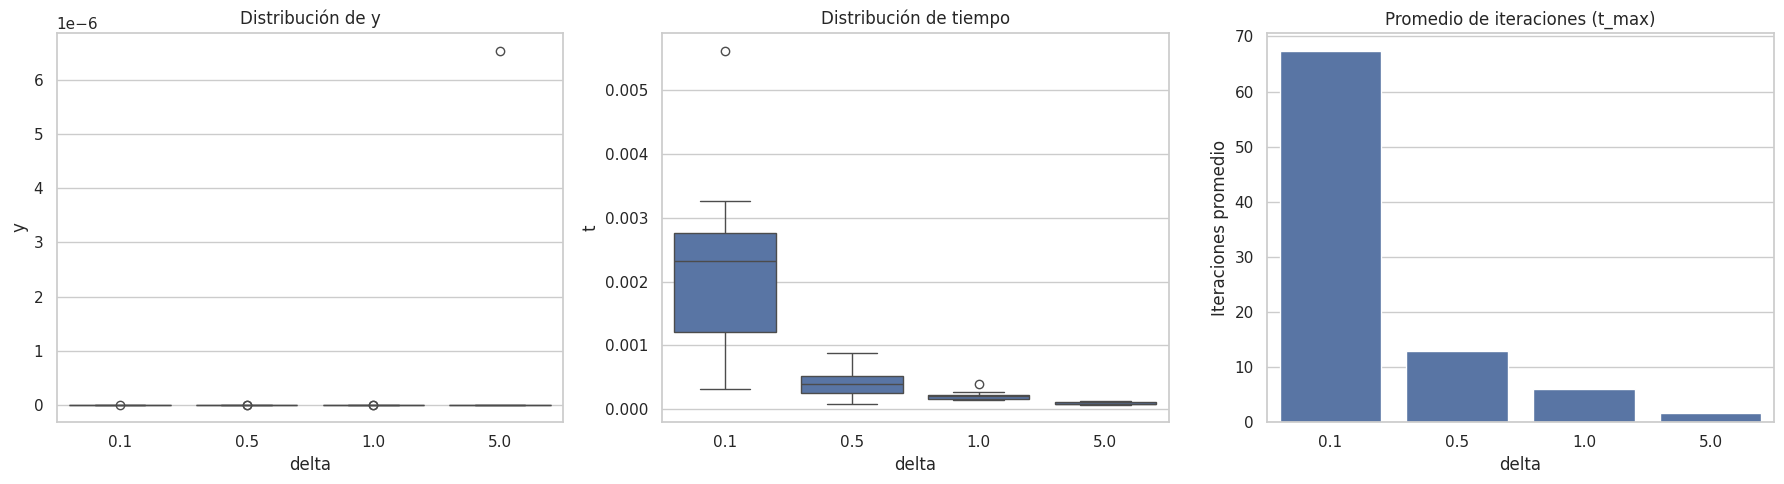

In [ ]:
#boxpltos
rows = []

for delta, res in results.items():
    for i in range(len(res['y'])):
        rows.append({
            "delta": float(delta),
            "y": res["y"][i],
            "t": res["t"][i],
            "t_max": res["t_max"][i]
        })

df_experiment_hill = pd.DataFrame(rows)
df_experiment_hill

fig, axs = plt.subplots(1, 3, figsize=(18, 5))


sns.boxplot(x='delta', y='y', data=df_experiment_hill, ax=axs[0])
axs[0].set_title("Distribución de y")


sns.boxplot(x='delta', y='t', data=df_experiment_hill, ax=axs[1])
axs[1].set_title("Distribución de tiempo")

mean_iters = df_experiment_hill.groupby('delta')['t_max'].mean().reset_index()

sns.barplot(x='delta', y='t_max', data=mean_iters, ax=axs[2])
axs[2].set_title("Promedio de iteraciones (t_max)")
axs[2].set_ylabel("Iteraciones promedio")

plt.tight_layout()
plt.show()


________________
**Preguntas de análisis**:

1. ¿Todos los valores de $\delta$ convergen al óptimo global ($x^*=3$) en una función convexa?
2. ¿Cómo influye $\delta$ en el número de evaluaciones necesarias? ¿Hay un valor óptimo?
3. ¿Valores muy grandes de $\delta$ causan "overshooting" (pasar de largo el óptimo)?
4. ¿Valores muy pequeños de $\delta$ requieren demasiadas iteraciones sin beneficio adicional?
5. Compare el número de evaluaciones de Hill Climbing con SGD. ¿Cuál es más eficiente en términos de evaluaciones de función?

**Respuestas**

1. Todos los valores de delta convergen al optimo global en la funcion convexa
2. A medida que incrementamos el delta, se reducen la cantidad de iteraciones promedio. El algoritmo explora mas pero puede perderse en precision
3. Si, el algoritmo por tener un delta grande puede pasar de largo y tener que volver.
4. Deltas muy pequeños implican mayor cantidad de iteraciones para converger
5. Hill climbing es mas preciso pero mas costoso!

### 3.4 Análisis de hiperparámetros en función no convexa

Evaluamos *Hill Climbing* en el desafiante paisaje multimodal de Schwefel, donde esperamos que su naturaleza puramente local lo haga vulnerable a quedar atrapado en óptimos locales.

> Minimice $f_2(x)$ usando los mismos valores de $\delta$. Realice **10 repeticiones** por valor con inicializaciones aleatorias en el dominio completo. Registre fitness, tiempo, evaluaciones y calcule la tasa de éxito ($f(x^*) < -400$).

> Complete una tabla similar a 3.3, incluyendo la tasa de éxito:

| $\delta$ | Fitness: Media ± IC | Fitness: Mediana | Fitness: Mejor | Tiempo [s]: Media ± IC | Evaluaciones: Media ± IC | Tasa éxito [%] |
|:--------:|:------------------:|:----------------:|:--------------:|:----------------------:|:------------------------:|:--------------:|
| 0.1 | ... | ... | ... | ... | ... | ... |
| 0.5 | ... | ... | ... | ... | ... | ... |
| 1.0 | ... | ... | ... | ... | ... | ... |
| 5.0 | ... | ... | ... | ... | ... | ... |

> Además, genere las siguientes visualizaciones:
> 1. Genere una figura con 4 subpaneles (uno por cada valor de $\delta$). En cada panel, grafique $f_2$ y superponga las 10 soluciones finales $x^*$ encontradas. Use colores para distinguir soluciones exitosas de las atrapadas en óptimos locales.
> 2. **Boxplot comparativo** con la distribución del fitness final para cada $\delta$. Compare la dispersión con la observada en $f_1$.
> 3. **Gráfico de barras de tasa de éxito**, mostrando cómo $\delta$ afecta la probabilidad de encontrar buenas soluciones. ¿Valores más grandes ayudan a "saltar" sobre óptimos locales?
> 4. **Histogramas de posiciones finales** mostrando la distribución espacial de las soluciones $x^*$ encontradas. ¿Se concentran en ciertas regiones (óptimos locales)?
> 5. **Análisis de atrapamiento**, graficando la función con marcas verticales en los óptimos locales más comunes donde Hill Climbing queda atrapado.


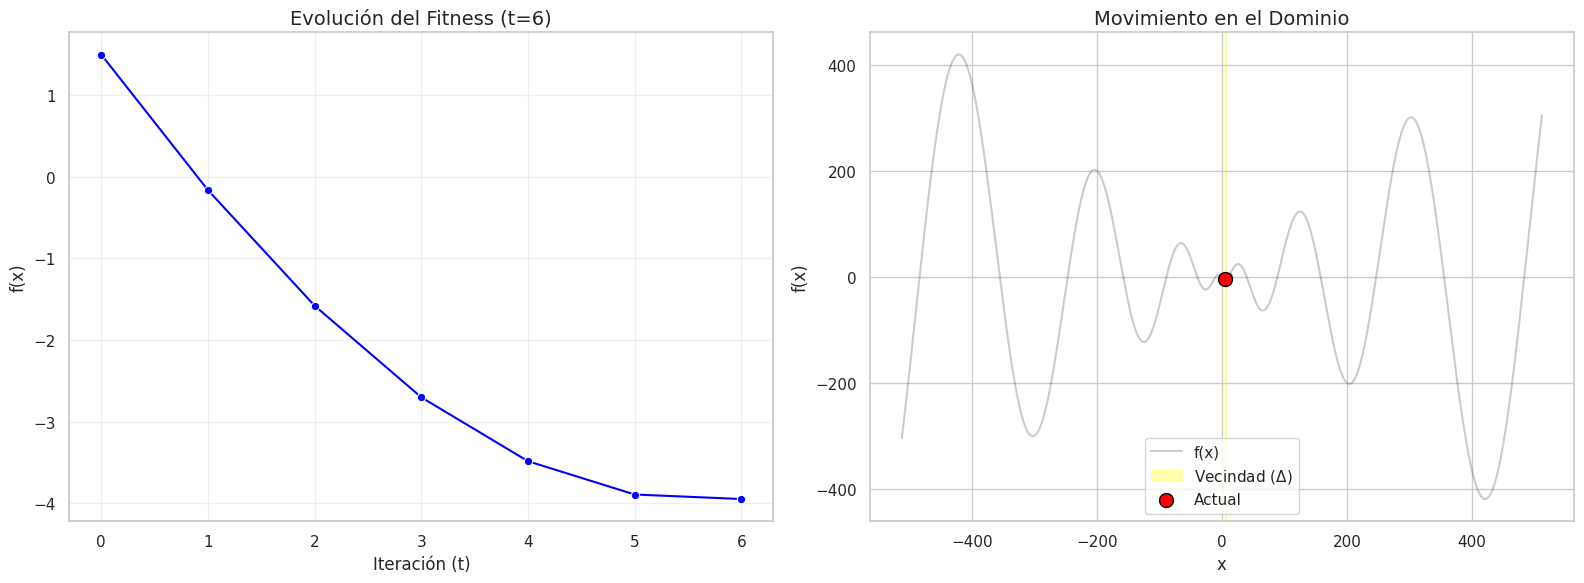

Convergencia alcanzada en t=6. Mínimo en x=5.2392, f(x)=-3.9453


(np.float64(5.239239239239281), np.float64(-3.9453016249622253))

In [ ]:
make_animated_optimization_HC(dom_f2, f_2, 1, -512, 512)

In [ ]:
deltas= [0.1, 0.5, 1.0, 5.0]
n_rep = 10

results = make_experiment_HC(
    function = f_2,
    deltas = deltas,
    k = n_rep,
    lower = dom_f2[0],
    upper = dom_f2[-1]
)

best_experiments['HC_non_cvx']= buscar_mejor_HC(results)
print(best_experiments)
df = info_experiment_HC(results, -400)
df


{'RS_cvx': {'N': '500'}, 'RS_non_cvx': {'N': '500'}, 'SGD_cvx': {'alpha': '0.5', 'beta': '0.0'}, 'SGD_non_cvx': {'alpha': '0.01', 'beta': '0.0'}, 'HC_cvx': {'delta': '0.5'}, 'HC_non_cvx': {'delta': '0.1'}}


,Delta,x media + IC,Fitness: media + IC,Fitness: mediana,Tiempo: media + IC,Evaluaciones_Media + IC,tasa de exito
0,0.1,181.53085999999615 +- 133.61941199811798,-245.25840281737314 +- 83.85554940559027,-201.843218,0.01557772159576416 +- 0.008431521351432594,294.9 +- 175.5154446491818,30.0
1,0.5,39.458100000000016 +- 196.76250370959553,-245.5773711359819 +- 96.44968848956962,-300.544553,0.004147028923034668 +- 0.001911426925624906,83.9 +- 40.357394742475634,30.0
2,1.0,-110.37319999999997 +- 162.1812312286035,-225.8952747661612 +- 67.57946072415497,-251.193885,0.0023341655731201174 +- 0.000666931371063359,46.1 +- 14.468066297885146,10.0
3,5.0,41.36440000000002 +- 141.62562697577573,-180.0645297856705 +- 89.3616659691348,-122.876172,0.0005364894866943359 +- 0.0002554448109601002,8.2 +- 4.328006654338692,20.0


<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:50: SyntaxWarning: invalid escape sequence '\g'
<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:50: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_990/1170076181.py:24: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(f'$\delta = {delta}$', fontsize=14)
/tmp/ipykernel_990/1170076181.py:50: SyntaxWarning: invalid escape sequence '\g'
  Line2D([0], [0], marker='o', color='w', label='Fallo ($\geq$ -400)',


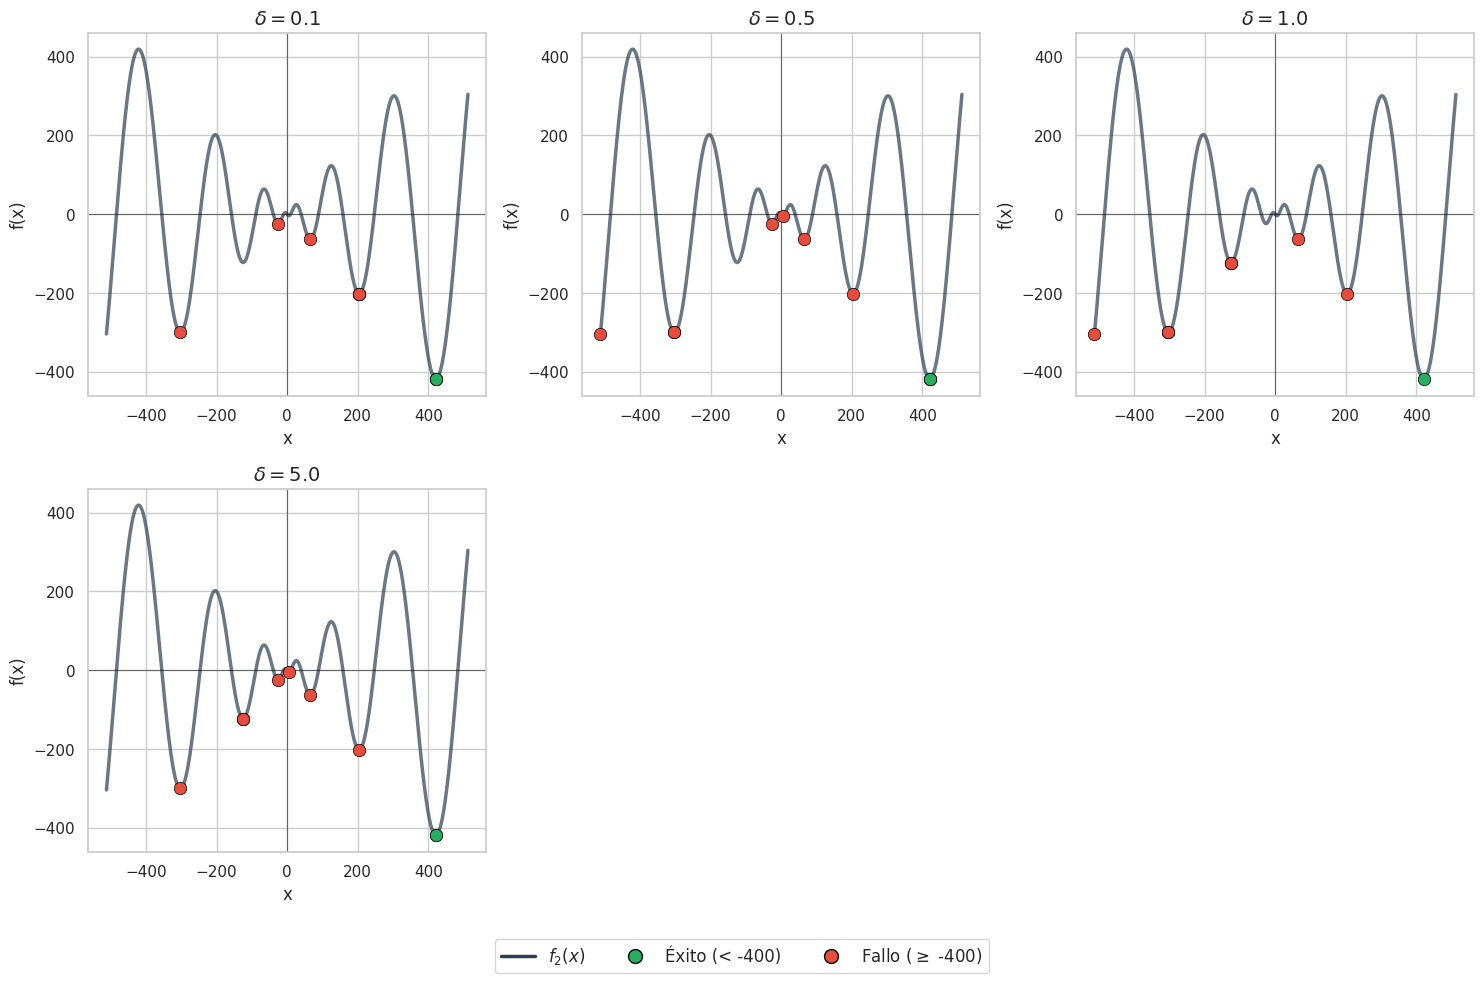

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np


#los poderosos encampeonados

# 2. Configuración de la figura (2 filas, 3 columnas según tu código)
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs_flat = axs.flatten()

# Colores definidos
color_linea = "#2c3e50"
color_exito = "#27ae60"
color_fallo = "#e74c3c"

# Iteración sobre los deltas
for i, delta in enumerate(deltas):
    ax = axs_flat[i]
    str_delta = str(delta)

    # Dibujar la función de fondo
    ax.plot(dom_f2, y_2, color=color_linea, linewidth=2.5, alpha=0.7)
    ax.set_title(f'$\delta = {delta}$', fontsize=14)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('f(x)', fontsize=12)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)

    # Extraer resultados de tu diccionario
    final_xs = results[str_delta]['x']
    final_ys = results[str_delta]['y']

    # Dibujar los puntos finales según el criterio de éxito
    for x_val, y_val in zip(final_xs, final_ys):
        if y_val < -400:
            ax.scatter(x_val, y_val, color=color_exito, s=80, zorder=5, edgecolors='black', linewidth=0.5)
        else:
            ax.scatter(x_val, y_val, color=color_fallo, s=80, zorder=5, edgecolors='black', linewidth=0.5)

# 4. Limpiar los subplots que queden vacíos (si sobran en la rejilla 2x3)
for j in range(len(deltas), len(axs_flat)):
    fig.delaxes(axs_flat[j])

# 5. Creación de la leyenda personalizada
leyenda_elementos = [
    Line2D([0], [0], color=color_linea, lw=2.5, label='$f_2(x)$'),
    Line2D([0], [0], marker='o', color='w', label='Éxito (< -400)',
           markerfacecolor=color_exito, markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Fallo ($\geq$ -400)',
           markerfacecolor=color_fallo, markersize=10, markeredgecolor='black')
]

fig.legend(handles=leyenda_elementos,
           loc='lower center',
           bbox_to_anchor=(0.5, 0.01),
           ncol=3,
           fontsize=12,
           frameon=True,
           facecolor='white')

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_990/2411902519.py:7: SyntaxWarning: invalid escape sequence '\d'
  ax1.set_title("Distribución de Fitness por $\delta$")
/tmp/ipykernel_990/2411902519.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(fitness_list, labels=deltas)


[np.float64(203.814199999999), np.float64(-25.87739999999997), np.float64(203.81420000000006), np.float64(420.9687999999851), np.float64(203.81419999999557), np.float64(-302.5249999999964), np.float64(420.9687999999894), np.float64(203.8141999999993), np.float64(420.9687999999894), np.float64(65.54779999999998), np.float64(420.969), np.float64(65.54800000000006), np.float64(-302.52500000000003), np.float64(420.96900000000005), np.float64(5.239000000000003), np.float64(-302.525), np.float64(-25.877000000000013), np.float64(420.96900000000005), np.float64(203.81400000000002), np.float64(-512.0), np.float64(420.96799999999996), np.float64(-302.52399999999994), np.float64(-302.524), np.float64(-124.82999999999998), np.float64(65.54799999999997), np.float64(-124.83), np.float64(-512.0), np.float64(-302.524), np.float64(203.81400000000002), np.float64(-124.82999999999997), np.float64(65.54600000000006), np.float64(420.968), np.float64(-124.83399999999997), np.float64(-302.526), np.float64(-1

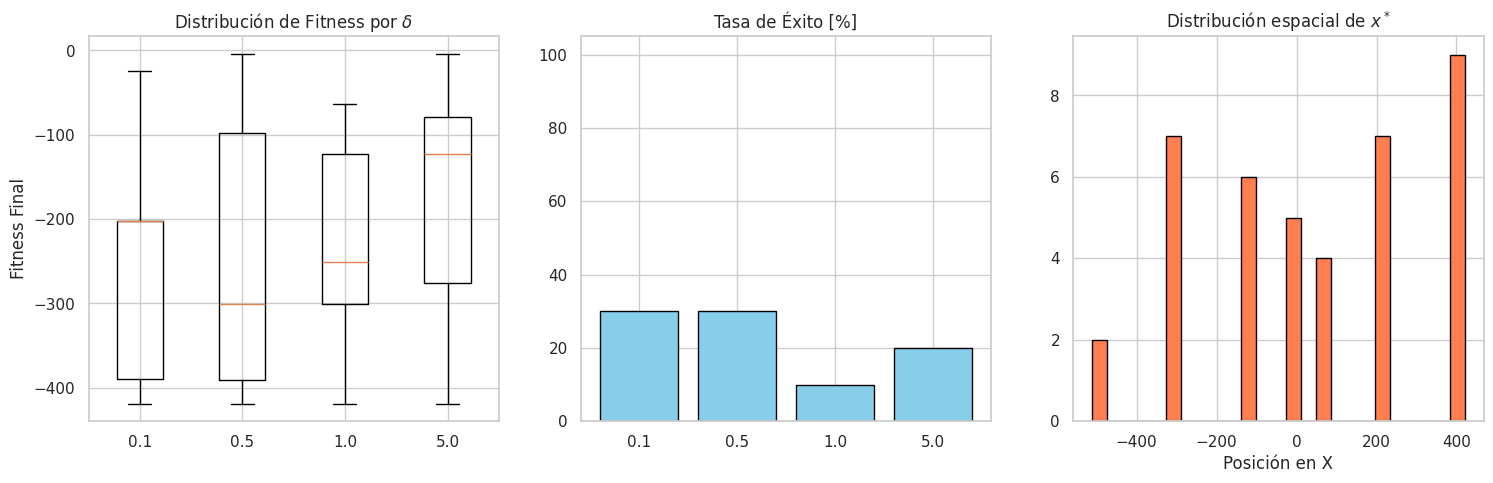

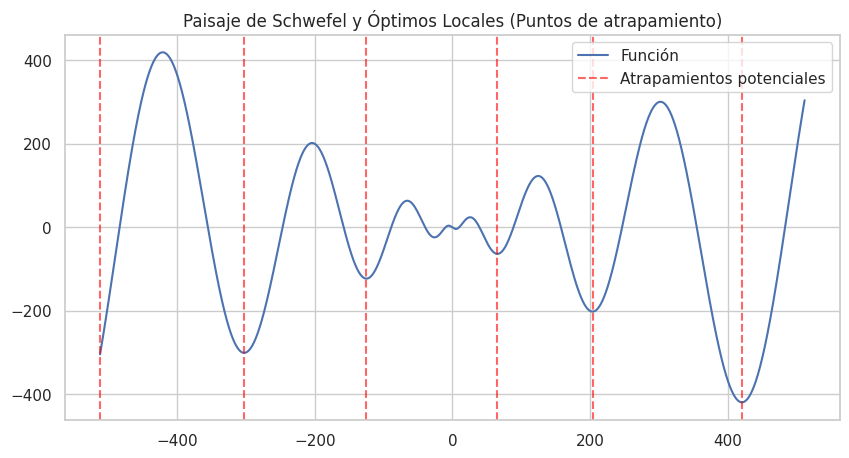

In [ ]:
# --- 2, 3 y 4. BOXPLOT, ÉXITO E HISTOGRAMA ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot
fitness_list = [results[str(d)]['y'] for d in deltas]
ax1.boxplot(fitness_list, labels=deltas)
ax1.set_title("Distribución de Fitness por $\delta$")
ax1.set_ylabel("Fitness Final")

# Tasa de éxito (Barra)
rates = [np.sum(np.array(results[str(d)]['y']) < -400) * 10 for d in deltas]
ax2.bar([str(d) for d in deltas], rates, color='skyblue', edgecolor='black')
ax2.set_title("Tasa de Éxito [%]")
ax2.set_ylim(0, 105)

# Histograma de posiciones finales
all_x = []
for d in deltas: all_x.extend(results[str(d)]['x'])
print(all_x)
ax3.hist(all_x, bins=25, color='coral', edgecolor='black')
ax3.set_title("Distribución espacial de $x^*$")
ax3.set_xlabel("Posición en X")

plt.show()

# --- 5. ANÁLISIS DE ATRAPAMIENTO ---
plt.figure(figsize=(10, 5))
plt.plot(dom_f2, f_2(dom_f2), label='Schwefel')
# Óptimos locales conocidos de Schwefel
locales = [-512,-302.5, -124.8, 65.5, 203.8, 420.9]
for loc in locales:
    plt.axvline(loc, color='red', linestyle='--', alpha=0.6)

plt.title("Paisaje de Schwefel y Óptimos Locales (Puntos de atrapamiento)")
plt.legend(['Función', 'Atrapamientos potenciales'])
plt.show()

**Preguntas de análisis**:

1. ¿Hill Climbing queda sistemáticamente atrapado en óptimos locales? ¿Con qué frecuencia alcanza el óptimo global?
2. ¿El tamaño de paso $\delta$ afecta significativamente la capacidad de escapar de óptimos locales, o el atrapamiento es inevitable por la naturaleza local del algoritmo?
3. Compare las tasas de éxito entre diferentes valores de $\delta$. ¿Hay un valor claramente superior?
4. Observando los histogramas de posiciones, ¿hay óptimos locales "atractores" donde múltiples ejecuciones convergen?
5. ¿Cómo se compara la tasa de éxito de Hill Climbing con la de SGD? ¿Y con Random Search?
6. ¿El número de evaluaciones hasta convergencia es consistente entre ejecuciones, o varía según dónde quede atrapado?
7. ¿Valores grandes de $\delta$ (e.g., 5.0) permiten mayor exploración, o simplemente causan movimientos erráticos?

---

1. SI! Es bastante aleatorio, llega bastante al minimo que se encuentra enm la frontera, y pocas veces llega al optimo global de la funcion.

2. Si, afecta, el $\delta$ modifica la capacidad del algoritmo de observar el paisaje de la funcion, aunque queda atrapado a veces en optimos locales

3. No "claramente" superior, pero mejora un poco $\delta = 1$ y $\delta=5$
respecto a los otros 2

4. Si, se concentran bastante en el ƒ(x)=-320 y el ƒ(x)=200

5. El Hill Climbing anda bastante mejor que el SGD, el sgd esta dependiendo mucho del valor de iniciacion, pero tiene que ver con la naturaleza de la funcion, el hecho de que ir hacia minimos locales "mejores", hace necesario que pase un maximo elevadisimo.

6. Si, en los algoritmos con delta menores, es mucho mayor la diferencia de iteraciones hasta convergencia. En el $\delta = 5$ es muy poca la diferencia entre ejecuciones

7. En cierto punto, tener movimientos "erraticos", permiten una mayor exploracion, si el objetivo es "explorar", esta consiguiendo encontrar minimos, con movimiento muy amplios.

## Sección 4: Análisis Comparativo Integral

Esta sección sintetiza los hallazgos de las secciones anteriores mediante una comparación sistemática de los tres algoritmos. El objetivo es comprender cuándo cada método es más apropiado y desarrollar criterios para la selección de algoritmos de optimización en función de las características del problema.

### 4.1 Comparación en función convexa

Comparamos el desempeño de los tres algoritmos en el escenario más favorable: una función unimodal convexa donde cualquier mínimo local es global.

> Minimice $f_1(x)$ usando las mejores configuraciones de hiperparámetros identificadas en las secciones previas:
> - **Random Search**: Mejor valor de $N$ (de la sección 1.3)
> - **SGD**: Mejor combinación $(\alpha, \beta)$ (de la sección 2.3)
> - **Hill Climbing**: Mejor valor de $\delta$ (de la sección 3.3)

In [ ]:
print(best_experiments)

{'RS_cvx': {'N': '500'}, 'RS_non_cvx': {'N': '500'}, 'SGD_cvx': {'alpha': '0.5', 'beta': '0.0'}, 'SGD_non_cvx': {'alpha': '0.01', 'beta': '0.0'}, 'HC_cvx': {'delta': '0.5'}, 'HC_non_cvx': {'delta': '0.1'}}


> Realice **10 repeticiones independientes** de cada algoritmo con inicializaciones aleatorias en $[-10, 10]$. Registre para cada ejecución: mejor fitness final, tiempo de ejecución, número de evaluaciones hasta convergencia.
> **Criterio de éxito**: Considere que una ejecución es exitosa si $|x^* - 3| < 0.01$, es decir, si la solución encontrada está dentro de 0.01 unidades del óptimo verdadero.

In [ ]:
import time

k_comp = 10

# Extraer mejores hiperparámetros
best_N = int(best_experiments['RS_cvx']['N'])
best_a = float(best_experiments['SGD_cvx']['alpha'])
best_b = float(best_experiments['SGD_cvx']['beta'])
best_d = float(best_experiments['HC_cvx']['delta'])

optimo_f1 = 3.0
criterio_exito = 0.01   # |x* - 3| < 0.01

rows = []

# --- Random Search ---
rs_x, rs_y, rs_t, rs_eval = [], [], [], []
for _ in range(k_comp):
    t0 = time.time()
    x, y = random_search(best_N, dom_f1, f_1)
    rs_t.append(time.time() - t0)
    rs_x.append(x)
    rs_y.append(y)
    rs_eval.append(best_N)          # RS evalúa exactamente N puntos

ic_y  = 1.96 * np.std(rs_y, ddof=1) / np.sqrt(k_comp)
ic_t  = 1.96 * np.std(rs_t, ddof=1) / np.sqrt(k_comp)
ic_ev = 1.96 * np.std(rs_eval, ddof=1) / np.sqrt(k_comp)
rows.append({
    'Algoritmo': f'Random Search (N={best_N})',
    'Fitness: Media ± IC': f'{np.mean(rs_y):.6f} ± {ic_y:.6f}',
    'Fitness: Mejor': f'{np.min(rs_y):.6f}',
    'Tiempo: Media ± IC (s)': f'{np.mean(rs_t):.6f} ± {ic_t:.6f}',
    'Evaluaciones: Media ± IC': f'{np.mean(rs_eval):.1f} ± {ic_ev:.1f}',
    'Tasa éxito (%)': (np.abs(np.array(rs_x) - optimo_f1) < criterio_exito).mean() * 100,
})

# --- SGD ---
sgd_x, sgd_y, sgd_t, sgd_eval = [], [], [], []
for _ in range(k_comp):
    opt = sgd(learning_rate=best_a, momentum=best_b,
              epsilon=1e-6, max_iter=1000,
              inner_limit=dom_f1[0], upper_limit=dom_f1[-1])
    t0 = time.time()
    x_opt = opt.optimize(f_1, grad_f_1)
    sgd_t.append(time.time() - t0)
    sgd_x.append(x_opt)
    sgd_y.append(f_1(x_opt))
    sgd_eval.append(opt.iter)

ic_y  = 1.96 * np.std(sgd_y, ddof=1) / np.sqrt(k_comp)
ic_t  = 1.96 * np.std(sgd_t, ddof=1) / np.sqrt(k_comp)
ic_ev = 1.96 * np.std(sgd_eval, ddof=1) / np.sqrt(k_comp)
rows.append({
    'Algoritmo': f'SGD (α={best_a}, β={best_b})',
    'Fitness: Media ± IC': f'{np.mean(sgd_y):.6f} ± {ic_y:.6f}',
    'Fitness: Mejor': f'{np.min(sgd_y):.6f}',
    'Tiempo: Media ± IC (s)': f'{np.mean(sgd_t):.6f} ± {ic_t:.6f}',
    'Evaluaciones: Media ± IC': f'{np.mean(sgd_eval):.1f} ± {ic_ev:.1f}',
    'Tasa éxito (%)': (np.abs(np.array(sgd_x) - optimo_f1) < criterio_exito).mean() * 100,
})

# --- Hill Climbing ---
hc_x, hc_y, hc_t, hc_eval = [], [], [], []
for _ in range(k_comp):
    opt = hill_climbing(best_d, dom_f1[0], dom_f1[-1])
    t0 = time.time()
    x_opt, y = opt.optimize(f_1)
    hc_t.append(time.time() - t0)
    hc_x.append(x_opt)
    hc_y.append(y)
    hc_eval.append(opt.t)

ic_y  = 1.96 * np.std(hc_y, ddof=1) / np.sqrt(k_comp)
ic_t  = 1.96 * np.std(hc_t, ddof=1) / np.sqrt(k_comp)
ic_ev = 1.96 * np.std(hc_eval, ddof=1) / np.sqrt(k_comp)
rows.append({
    'Algoritmo': f'Hill Climbing (δ={best_d})',
    'Fitness: Media ± IC': f'{np.mean(hc_y):.6f} ± {ic_y:.6f}',
    'Fitness: Mejor': f'{np.min(hc_y):.6f}',
    'Tiempo: Media ± IC (s)': f'{np.mean(hc_t):.6f} ± {ic_t:.6f}',
    'Evaluaciones: Media ± IC': f'{np.mean(hc_eval):.1f} ± {ic_ev:.1f}',
    'Tasa éxito (%)': (np.abs(np.array(hc_x) - optimo_f1) < criterio_exito).mean() * 100,
})

df_comp_f1 = pd.DataFrame(rows).set_index('Algoritmo')
df_comp_f1


,Fitness: Media ± IC,Fitness: Mejor,Tiempo: Media ± IC (s),Evaluaciones: Media ± IC,Tasa éxito (%)
Algoritmo,,,,,
Random Search (N=500),0.000658 ± 0.000653,0.000002,0.000613 ± 0.000118,500.0 ± 0.0,50.0
"SGD (α=0.5, β=0.0)",0.000000 ± 0.000000,0.000000,0.000022 ± 0.000008,2.0 ± 0.0,100.0
Hill Climbing (δ=0.5),0.000000 ± 0.000000,0.000000,0.000413 ± 0.000106,15.1 ± 4.6,100.0


**Tabla resumen**:
| Algoritmo | Hiperparámetros | Fitness: Media ± IC | Tiempo [s]: Media ± IC | Evaluaciones: Media ± IC | Tasa éxito [%] |
|:---------:|:---------------:|:-------------------:|:----------------------:|:------------------------:|:--------------:|
| Random Search | $N = $ ... | ... | ... | ... | ... |
| SGD | $\alpha=..., \beta=...$ | ... | ... | ... | ... |
| Hill Climbing | $\delta=...$ | ... | ... | ... | ... |

> Además, genere las siguientes visualizaciones:
> 1. **Boxplot comparativo de fitness**, mostrando lado a lado la distribución del fitness final de cada algoritmo.
> 2. **Gráfico de barras de tiempo de ejecución**, con barras de error representando IC, comparando el tiempo promedio para los 3 algoritmos.

/tmp/ipykernel_990/1819330149.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([rs_y, sgd_y, hc_y], labels=labels, patch_artist=True,


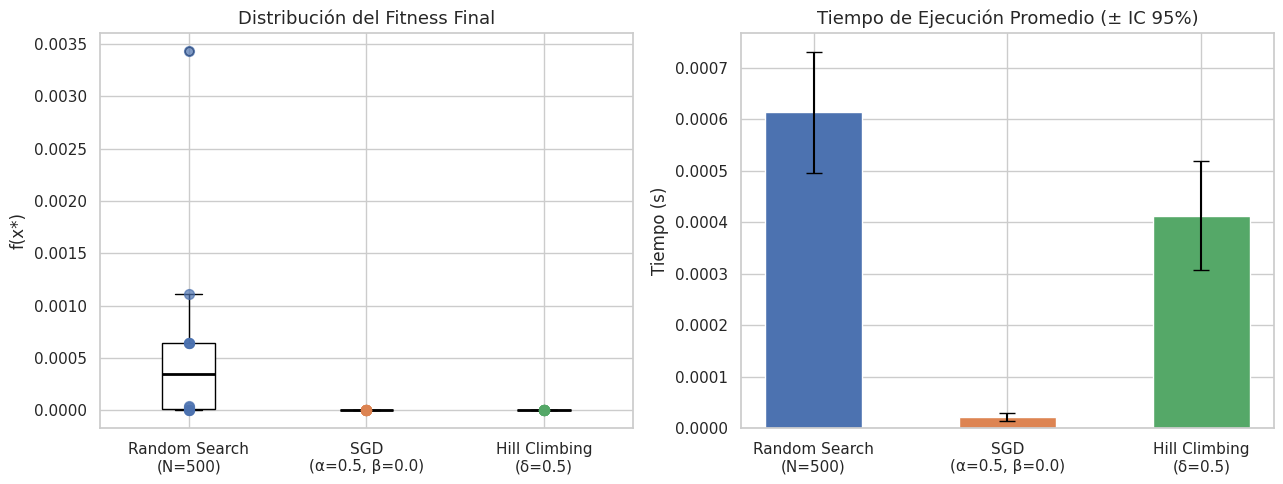

In [ ]:
labels = [
    f'Random Search\n(N={best_N})',
    f'SGD\n(α={best_a}, β={best_b})',
    f'Hill Climbing\n(δ={best_d})',
]
colores = ['#4C72B0', '#DD8452', '#55A868']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sns.set_theme(style='whitegrid')

# --- Boxplot de fitness ---
ax1.boxplot([rs_y, sgd_y, hc_y], labels=labels, patch_artist=True,
            boxprops=dict(facecolor='white'),
            medianprops=dict(color='black', linewidth=2))
for i, (data, color) in enumerate(zip([rs_y, sgd_y, hc_y], colores)):
    ax1.scatter([i+1]*len(data), data, color=color, alpha=0.7, zorder=3, s=50)
ax1.set_title('Distribución del Fitness Final', fontsize=13)
ax1.set_ylabel('f(x*)')

# --- Barras de tiempo con IC ---
medias_t = [np.mean(rs_t), np.mean(sgd_t), np.mean(hc_t)]
ics_t    = [1.96 * np.std(v, ddof=1) / np.sqrt(k_comp) for v in [rs_t, sgd_t, hc_t]]

x = np.arange(len(labels))
bars = ax2.bar(x, medias_t, color=colores, edgecolor='white', width=0.5)
ax2.errorbar(x, medias_t, yerr=ics_t, fmt='none', color='black',
             capsize=6, linewidth=1.5)
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_title('Tiempo de Ejecución Promedio (± IC 95%)', fontsize=13)
ax2.set_ylabel('Tiempo (s)')

plt.tight_layout()
plt.show()


**Análisis**:

1. ¿Todos los algoritmos alcanzan el óptimo global consistentemente? (esperamos tasa de éxito del 100% en los tres)
2. ¿Cuál algoritmo requiere menos evaluaciones de función? ¿Y menos tiempo de ejecución?
3. ¿Hay diferencias significativas en la precisión final (qué tan cerca del óptimo llegan)?
4. Considerando simplicidad de implementación, ¿cuál recomendaría para optimizar funciones convexas simples en la práctica?
5. ¿El "ganador" cambia si priorizamos velocidad vs precisión vs simplicidad?

### 4.2 Análisis de robustez frente a inicialización (función no convexa)

En funciones multimodales, la inicialización puede determinar críticamente el resultado de algoritmos de búsqueda local. Este experimento cuantifica cómo la región de inicialización afecta la probabilidad de encontrar el óptimo global.

> Dividimos el dominio $[-512, 512]$ de la función de Schwefel en seis regiones:
> - $R_1$: $[-512, 512]$ (dominio completo)
> - $R_2$: $[-512, -300]$ (extremo izquierdo)
> - $R_3$: $[-300, -100]$ (centro-izquierda)
> - $R_4$: $[-100, 100]$ (centro)
> - $R_5$: $[100, 300]$ (centro-derecha)
> - $R_6$: $[300, 512]$ (extremo derecho, contiene el óptimo global $x^* \approx 420.97$)
> Para cada combinación de [algoritmo, región]:
> - Use los mejores hiperparámetros identificados previamente
> - Realice **10 repeticiones** con inicializaciones aleatorias dentro de la región especificada
> - Registre: fitness final, tiempo de ejecución, número de evaluaciones

In [ ]:
import time

k_reg = 10

# Mejores hiperparámetros (función no convexa)
best_N_nc = int(best_experiments['RS_non_cvx']['N'])
best_a_nc = float(best_experiments['SGD_non_cvx']['alpha'])
best_b_nc = float(best_experiments['SGD_non_cvx']['beta'])
best_d_nc = float(best_experiments['HC_non_cvx']['delta'])

regiones = {
    'R1: [-512, 512]':   (-512,  512),
    'R2: [-512, -300]':  (-512, -300),
    'R3: [-300, -100]':  (-300, -100),
    'R4: [-100,  100]':  (-100,  100),
    'R5: [100,   300]':  ( 100,  300),
    'R6: [300,   512]':  ( 300,  512),
}

rows = []

for region_name, (lo, hi) in regiones.items():
    dom_region = np.linspace(lo, hi, 1000)

    # --- Random Search ---
    rs_x, rs_y, rs_t = [], [], []
    for _ in range(k_reg):
        t0 = time.time()
        x, y = random_search(best_N_nc, dom_region, f_2)
        rs_t.append(time.time() - t0)
        rs_x.append(x); rs_y.append(y)
    ic_y = 1.96 * np.std(rs_y, ddof=1) / np.sqrt(k_reg)
    ic_t = 1.96 * np.std(rs_t, ddof=1) / np.sqrt(k_reg)
    rows.append({
        'Región': region_name,
        'Algoritmo': f'RS (N={best_N_nc})',
        'Fitness: Media ± IC': f'{np.mean(rs_y):.2f} ± {ic_y:.2f}',
        'Fitness: Mejor': round(np.min(rs_y), 4),
        'Tiempo medio (s)': f'{np.mean(rs_t):.5f} ± {ic_t:.5f}',
        'Evaluaciones': best_N_nc,
        'Tasa éxito (%)': (np.array(rs_y) < -400).mean() * 100,
    })

    # --- SGD ---
    sgd_x, sgd_y, sgd_t, sgd_eval = [], [], [], []
    for _ in range(k_reg):
        opt = sgd(
            learning_rate=best_a_nc,
            momentum=best_b_nc,
            epsilon=1e-6,
            max_iter=1000,
            inner_limit=lo,
            upper_limit=hi
        )
        t0 = time.time()
        x_opt = opt.optimize(f_2, grad_f_2)
        sgd_t.append(time.time() - t0)
        sgd_x.append(x_opt); sgd_y.append(f_2(x_opt)); sgd_eval.append(opt.iter)
    ic_y = 1.96 * np.std(sgd_y, ddof=1) / np.sqrt(k_reg)
    ic_t = 1.96 * np.std(sgd_t, ddof=1) / np.sqrt(k_reg)
    ic_ev = 1.96 * np.std(sgd_eval, ddof=1) / np.sqrt(k_reg)
    rows.append({
        'Región': region_name,
        'Algoritmo': f'SGD (α={best_a_nc}, β={best_b_nc})',
        'Fitness: Media ± IC': f'{np.mean(sgd_y):.2f} ± {ic_y:.2f}',
        'Fitness: Mejor': round(np.min(sgd_y), 4),
        'Tiempo medio (s)': f'{np.mean(sgd_t):.5f} ± {ic_t:.5f}',
        'Evaluaciones': round(np.mean(sgd_eval), 1),
        'Tasa éxito (%)': (np.array(sgd_y) < -400).mean() * 100,
    })

    # --- Hill Climbing ---
    hc_x, hc_y, hc_t, hc_eval = [], [], [], []
    for _ in range(k_reg):
        opt = hill_climbing(best_d_nc, lo, hi)
        t0 = time.time()
        x_opt, y = opt.optimize(f_2)
        hc_t.append(time.time() - t0)
        hc_x.append(x_opt); hc_y.append(y); hc_eval.append(opt.t)
    ic_y = 1.96 * np.std(hc_y, ddof=1) / np.sqrt(k_reg)
    ic_t = 1.96 * np.std(hc_t, ddof=1) / np.sqrt(k_reg)
    ic_ev = 1.96 * np.std(hc_eval, ddof=1) / np.sqrt(k_reg)
    rows.append({
        'Región': region_name,
        'Algoritmo': f'HC (δ={best_d_nc})',
        'Fitness: Media ± IC': f'{np.mean(hc_y):.2f} ± {ic_y:.2f}',
        'Fitness: Mejor': round(np.min(hc_y), 4),
        'Tiempo medio (s)': f'{np.mean(hc_t):.5f} ± {ic_t:.5f}',
        'Evaluaciones': round(np.mean(hc_eval), 1),
        'Tasa éxito (%)': (np.array(hc_y) < -400).mean() * 100,
    })

df_regiones = pd.DataFrame(rows).set_index(['Región', 'Algoritmo'])
df_regiones


Fitness: Media ± IC  Fitness: Mejor  \
Región           Algoritmo                                                 
R1: [-512, 512]  RS (N=500)               -418.89 ± 0.08       -418.9780   
                 SGD (α=0.01, β=0.0)     -233.41 ± 48.37       -304.2295   
                 HC (δ=0.1)              -189.98 ± 77.65       -418.9829   
R2: [-512, -300] RS (N=500)               -303.08 ± 0.98       -304.2295   
                 SGD (α=0.01, β=0.0)     -286.31 ± 26.19       -304.2295   
                 HC (δ=0.1)               -301.65 ± 1.10       -304.2295   
R3: [-300, -100] RS (N=500)               -299.64 ± 0.07       -299.7386   
                 SGD (α=0.01, β=0.0)    -106.80 ± 110.63       -298.4713   
                 HC (δ=0.1)              -193.62 ± 56.61       -299.7386   
R4: [-100,  100] RS (N=500)                -63.63 ± 0.00        -63.6349   
                 SGD (α=0.01, β=0.0)      -25.36 ± 22.97        -59.7839   
                 HC (δ=0.1)               -43.03 ± 13.49        -63.6350   
R5: [100,   300] RS (N=500)               -201.83 ± 0.02       -201.8422   
                 SGD (α=0.01, β=0.0)     -15.49 ± 106.49       -197.9127   
                 HC (δ=0.1)              -150.59 ± 66.97       -201.8432   
R6: [300,   512] RS (N=500)               -418.98 ± 0.00       -418.9829   
                 SGD (α=0.01, β=0.0)     -400.39 ± 18.79       -418.9605   
                 HC (δ=0.1)               -418.98 ± 0.00       -418.9829   

                                       Tiempo medio (s)  Evaluaciones  \
Región           Algoritmo                                              
R1: [-512, 512]  RS (N=500)           0.00184 ± 0.00008         500.0   
                 SGD (α=0.01, β=0.0)  0.02129 ± 0.00064        1000.0   
                 HC (δ=0.1)           0.01847 ± 0.01156         381.7   
R2: [-512, -300] RS (N=500)           0.00192 ± 0.00009         500.0   
                 SGD (α=0.01, β=0.0)  0.02281 ± 0.00160        1000.0   
                 HC (δ=0.1)           0.02340 ± 0.01074         509.2   
R3: [-300, -100] RS (N=500)           0.00174 ± 0.00003         500.0   
                 SGD (α=0.01, β=0.0)  0.02299 ± 0.00215        1000.0   
                 HC (δ=0.1)           0.01522 ± 0.00606         326.9   
R4: [-100,  100] RS (N=500)           0.00178 ± 0.00005         500.0   
                 SGD (α=0.01, β=0.0)  0.02323 ± 0.00127        1000.0   
                 HC (δ=0.1)           0.00726 ± 0.00374         153.3   
R5: [100,   300] RS (N=500)           0.00175 ± 0.00004         500.0   
                 SGD (α=0.01, β=0.0)  0.02162 ± 0.00046        1000.0   
                 HC (δ=0.1)           0.01919 ± 0.00973         381.8   
R6: [300,   512] RS (N=500)           0.00245 ± 0.00051         500.0   
                 SGD (α=0.01, β=0.0)  0.02130 ± 0.00038        1000.0   
                 HC (δ=0.1)           0.01707 ± 0.00645         345.7   

                                      Tasa éxito (%)  
Región           Algoritmo                            
R1: [-512, 512]  RS (N=500)                    100.0  
                 SGD (α=0.01, β=0.0)             0.0  
                 HC (δ=0.1)                     10.0  
R2: [-512, -300] RS (N=500)                      0.0  
                 SGD (α=0.01, β=0.0)             0.0  
                 HC (δ=0.1)                      0.0  
R3: [-300, -100] RS (N=500)                      0.0  
                 SGD (α=0.01, β=0.0)             0.0  
                 HC (δ=0.1)                      0.0  
R4: [-100,  100] RS (N=500)                      0.0  
                 SGD (α=0.01, β=0.0)             0.0  
                 HC (δ=0.1)                      0.0  
R5: [100,   300] RS (N=500)                      0.0  
                 SGD (α=0.01, β=0.0)             0.0  
                 HC (δ=0.1)                      0.0  
R6: [300,   512] RS (N=500)                    100.0  
                 SGD (α=0.01, β=0.0)            70.0  
          

> Realice las siguientes figuras para comparar el desempeño:
> 1. **Gráfico multi-panel de soluciones (6 paneles)**: Genere una figura con 6 subpaneles verticales, uno por cada región. En cada panel:
>    - Grafique $f_2(x)$ en todo el dominio $[-512, 512]$
>    - Superponga las soluciones finales encontradas por los tres algoritmos (10 repeticiones × 3 algoritmos = 30 puntos por panel)
>    - Use colores/símbolos distintos para cada algoritmo
>    - Marque el óptimo global con una línea vertical o estrella
>    - Título del panel: nombre de la región (e.g., "Región $R_6$: [300, 512]")
> 2. **Boxplots por región (6 paneles)**: Similar al anterior, pero ahora cada panel muestra tres boxplots (uno por algoritmo) representando la distribución del fitness final en las 10 repeticiones de esa región.
> 3. **Gráfico de barras agrupadas de tiempo**: Eje X = regiones, barras agrupadas por algoritmo, altura = tiempo promedio. Este gráfico revela si algún algoritmo es consistentemente más rápido independientemente de la inicialización.

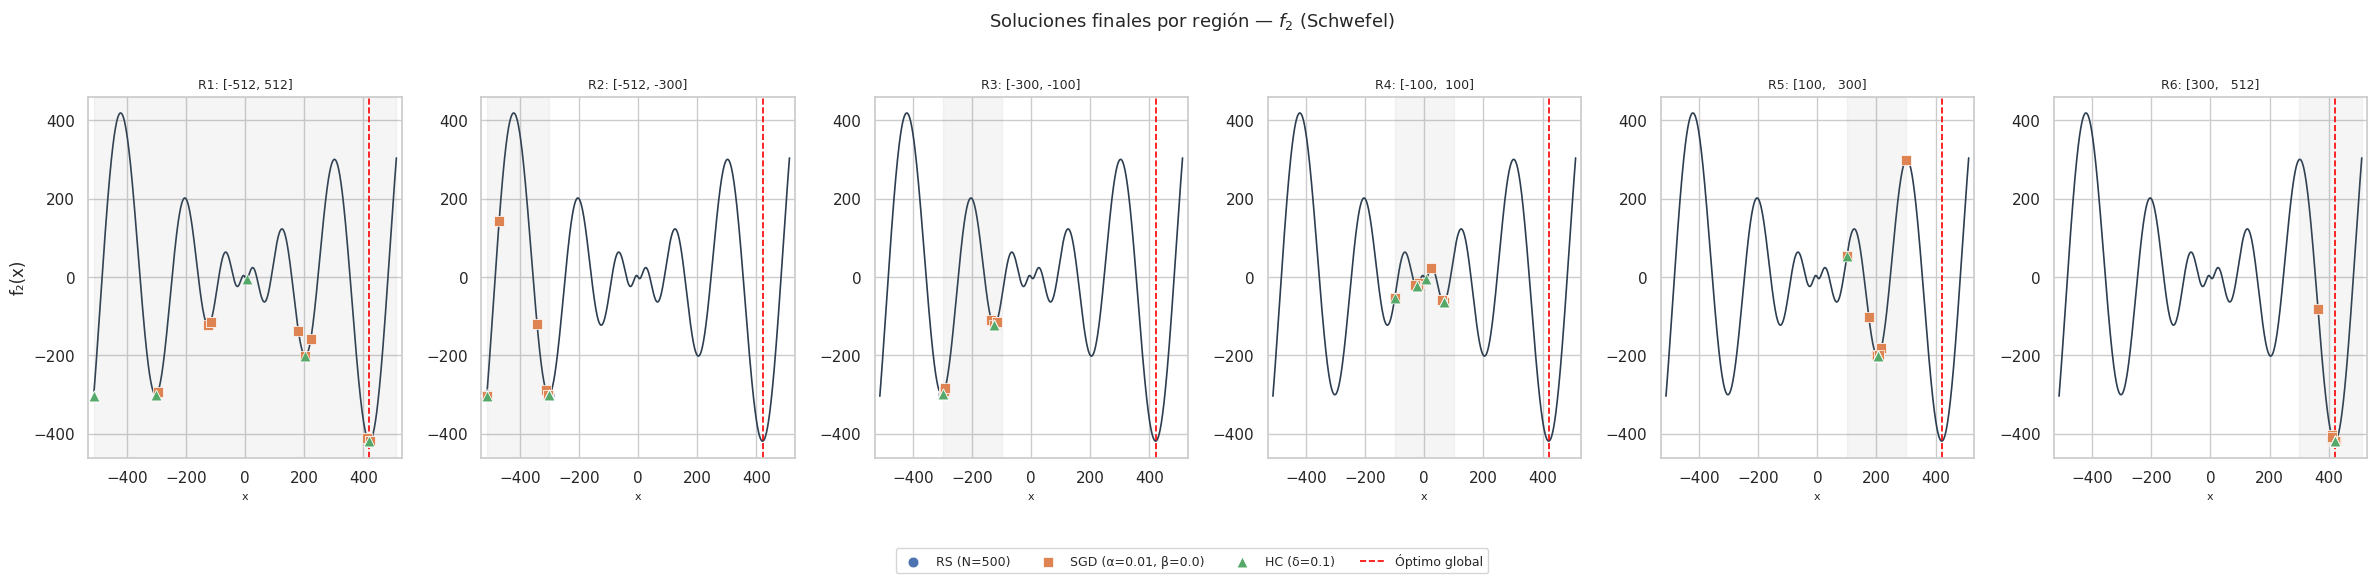

In [ ]:
x_optimo_f2 = 420.9687

dom_plot = np.linspace(-512, 512, 2000)
y_plot = np.array([f_2(x) for x in dom_plot])

regiones = {
    'R1: [-512, 512]':   (-512,  512),
    'R2: [-512, -300]':  (-512, -300),
    'R3: [-300, -100]':  (-300, -100),
    'R4: [-100,  100]':  (-100,  100),
    'R5: [100,   300]':  ( 100,  300),
    'R6: [300,   512]':  ( 300,  512),
}

k_reg = 10
best_N_nc = int(best_experiments['RS_non_cvx']['N'])
best_a_nc = float(best_experiments['SGD_non_cvx']['alpha'])
best_b_nc = float(best_experiments['SGD_non_cvx']['beta'])
best_d_nc = float(best_experiments['HC_non_cvx']['delta'])

colores  = {'RS': '#4C72B0', 'SGD': '#DD8452', 'HC': '#55A868'}
markers  = {'RS': 'o',       'SGD': 's',        'HC': '^'}
etiquetas = {
    'RS':  f'RS (N={best_N_nc})',
    'SGD': f'SGD (α={best_a_nc}, β={best_b_nc})',
    'HC':  f'HC (δ={best_d_nc})',
}

# Recolectar soluciones por región
resultados = {}
for region_name, (lo, hi) in regiones.items():
    dom_region = np.linspace(lo, hi, 1000)
    resultados[region_name] = {}

    # RS
    xs, ys, ts = [], [], []
    for _ in range(k_reg):
        x, y = random_search(best_N_nc, dom_region, f_2)
        t0 = time.time()
        ts.append(time.time() - t0)
        xs.append(x); ys.append(y)
    resultados[region_name]['RS'] = (xs, ys, ts)

    # SGD
    xs, ys, ts = [], [], []
    for _ in range(k_reg):
        opt = sgd(learning_rate=best_a_nc, momentum=best_b_nc,
                  epsilon=1e-6, max_iter=1000,
                  inner_limit=lo, upper_limit=hi)
        t0 = time.time()
        xo = opt.optimize(f_2, grad_f_2)
        ts.append(time.time() - t0)
        xs.append(xo); ys.append(f_2(xo))
    resultados[region_name]['SGD'] = (xs, ys, ts)

    # HC
    xs, ys, ts = [], [], []
    for _ in range(k_reg):
        opt = hill_climbing(best_d_nc, lo, hi)
        t0 = time.time()
        xo, yo = opt.optimize(f_2)
        ts.append(time.time() - t0)
        xs.append(xo); ys.append(yo)
    resultados[region_name]['HC'] = (xs, ys, ts)

# Graficar
fig, axs = plt.subplots(1, 6, figsize=(24, 5), sharey=False)
sns.set_theme(style='whitegrid')

for ax, (region_name, (lo, hi)) in zip(axs, regiones.items()):
    ax.plot(dom_plot, y_plot, color='#2c3e50', linewidth=1.2, zorder=1)
    ax.axvspan(lo, hi, alpha=0.08, color='gray')

    for alg in ['RS', 'SGD', 'HC']:
        xs, ys, _ = resultados[region_name][alg]
        ax.scatter(xs, ys, color=colores[alg], marker=markers[alg],
                   s=60, zorder=3, label=etiquetas[alg],
                   edgecolors='white', linewidths=0.5)

    ax.axvline(x_optimo_f2, color='red', linestyle='--',
               linewidth=1.2, zorder=2, label='Óptimo global')
    ax.set_title(region_name, fontsize=9)
    ax.set_xlabel('x', fontsize=8)
    ax.set_xlim(-530, 530)

axs[0].set_ylabel('f₂(x)')
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.12), fontsize=9)
fig.suptitle('Soluciones finales por región — $f_2$ (Schwefel)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


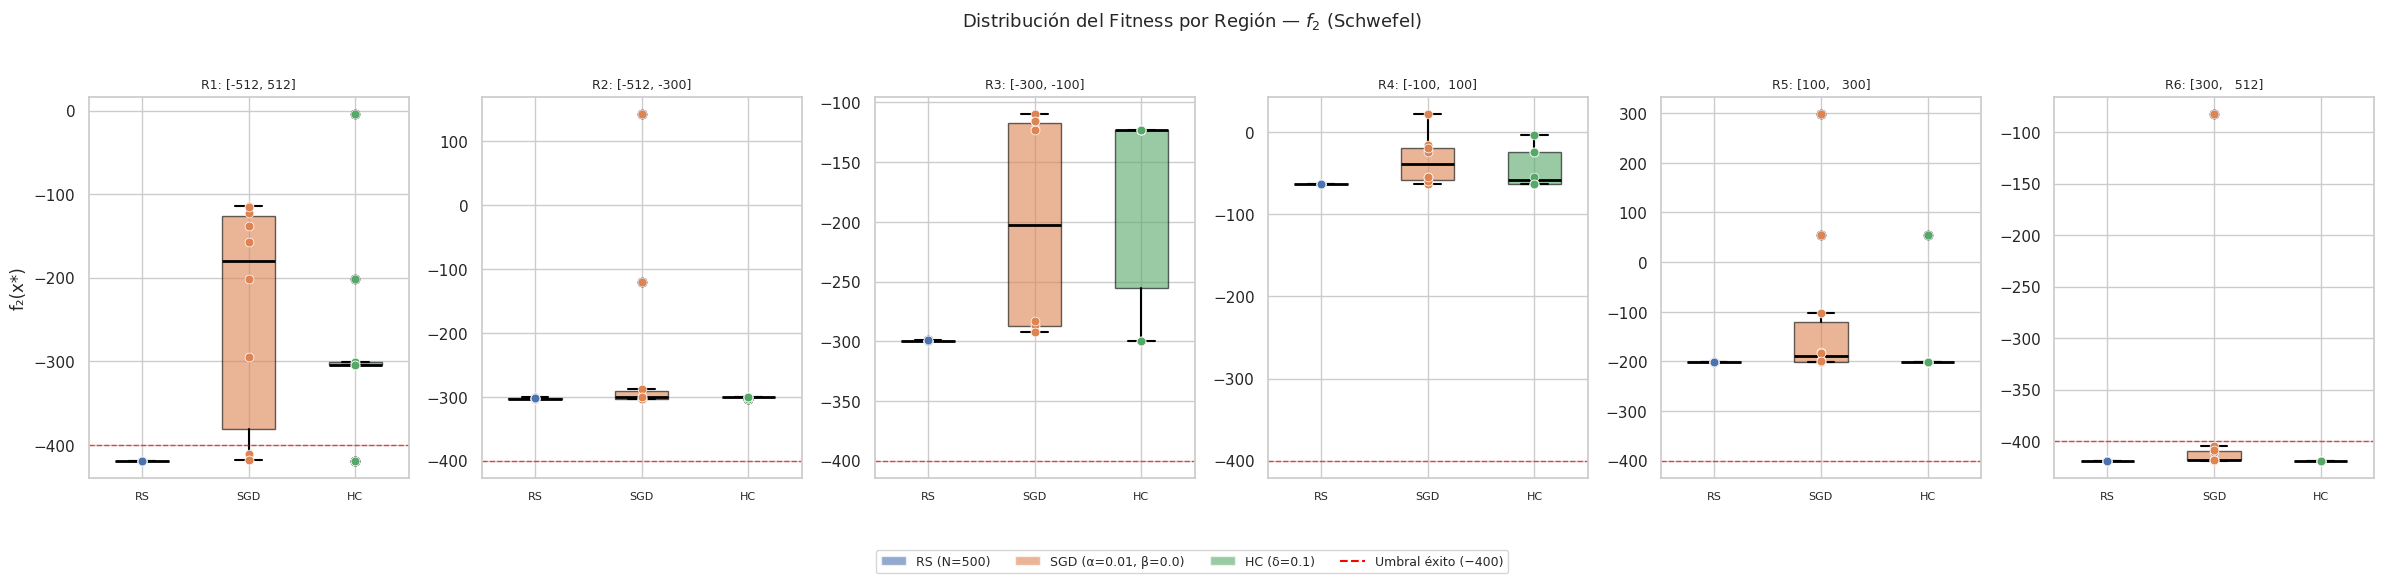

In [ ]:
fig, axs = plt.subplots(1, 6, figsize=(24, 5), sharey=False)
sns.set_theme(style='whitegrid')

for ax, (region_name, (lo, hi)) in zip(axs, regiones.items()):
    datos = [resultados[region_name][alg][1] for alg in ['RS', 'SGD', 'HC']]
    bp = ax.boxplot(datos, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))

    for patch, alg in zip(bp['boxes'], ['RS', 'SGD', 'HC']):
        patch.set_facecolor(colores[alg])
        patch.set_alpha(0.6)

    for alg_idx, alg in enumerate(['RS', 'SGD', 'HC']):
        ys = resultados[region_name][alg][1]
        ax.scatter([alg_idx + 1] * len(ys), ys,
                   color=colores[alg], s=40, zorder=3,
                   edgecolors='white', linewidths=0.5)

    ax.set_title(region_name, fontsize=9)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['RS', 'SGD', 'HC'], fontsize=8)
    ax.set_ylabel('f₂(x*)' if ax == axs[0] else '')
    ax.axhline(-400, color='red', linestyle='--', linewidth=1, alpha=0.7)

axs[0].set_ylabel('f₂(x*)')
fig.suptitle('Distribución del Fitness por Región — $f_2$ (Schwefel)', fontsize=13, y=1.02)

from matplotlib.patches import Patch
leyenda = [Patch(facecolor=colores[alg], alpha=0.6, label=etiquetas[alg])
           for alg in ['RS', 'SGD', 'HC']]
leyenda.append(plt.Line2D([0], [0], color='red', linestyle='--', label='Umbral éxito (−400)'))
fig.legend(handles=leyenda, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.12), fontsize=9)

plt.tight_layout()
plt.show()


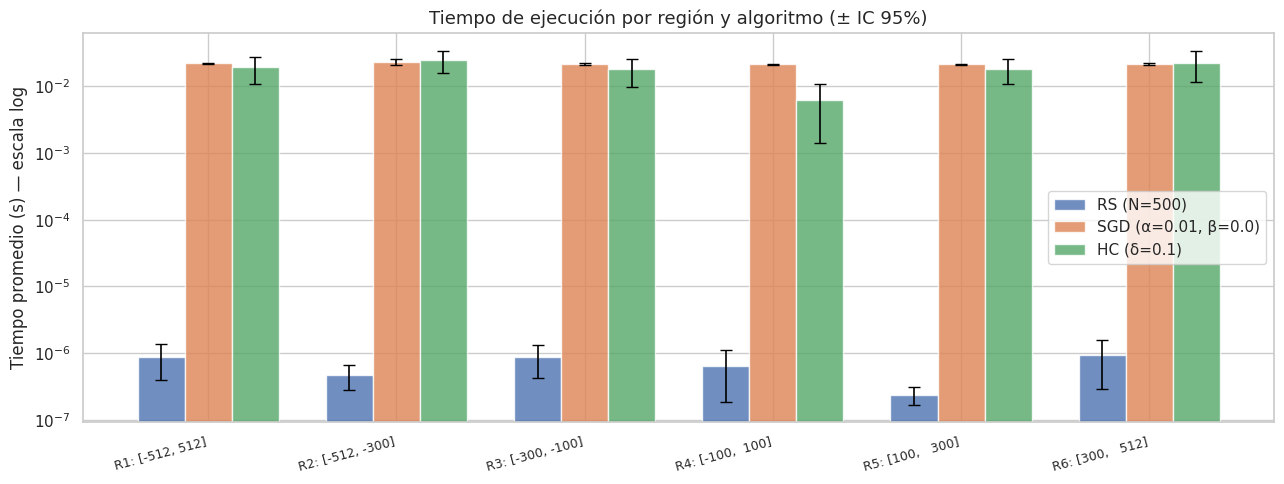

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_theme(style='whitegrid')

nombres_regiones = list(regiones.keys())

x = np.arange(len(nombres_regiones))
width = 0.25

for i, alg in enumerate(['RS', 'SGD', 'HC']):
    medias = [np.mean(resultados[r][alg][2]) for r in nombres_regiones]
    ics    = [1.96 * np.std(resultados[r][alg][2], ddof=1) / np.sqrt(k_reg)
              for r in nombres_regiones]
    ax.bar(x + i * width, medias, width, label=etiquetas[alg],
           color=colores[alg], alpha=0.8, edgecolor='white')
    ax.errorbar(x + i * width, medias, yerr=ics,
                fmt='none', color='black', capsize=4, linewidth=1.2)

ax.set_xticks(x + width)
ax.set_xticklabels(nombres_regiones, rotation=15, ha='right', fontsize=9)
ax.set_yscale('log')
ax.set_ylabel('Tiempo promedio (s) — escala log')
ax.set_title('Tiempo de ejecución por región y algoritmo (± IC 95%)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


> Calcule el porcentaje de ejecuciones que alcanzaron $f(x^*) < -400$ (cercano al óptimo) para cada combinación [algoritmo, región]. Complete la siguiente tabla de tasa de éxito por región:

In [ ]:
umbral = -400

tabla = {}
for alg, etiqueta in [('RS', 'Random Search'), ('SGD', 'SGD'), ('HC', 'Hill Climbing')]:
    fila = {}
    for region_name in regiones:
        ys = np.array(resultados[region_name][alg][1])
        fila[region_name] = (ys < umbral).mean() * 100
    fila['Promedio'] = np.mean(list(fila.values()))
    tabla[etiqueta] = fila

df_tasa = pd.DataFrame(tabla).T
df_tasa.index.name = 'Algoritmo / Región'
df_tasa.columns = [c.replace('R', '$R_').replace(']', ']$') if c != 'Promedio' else c
                   for c in df_tasa.columns]
df_tasa = df_tasa.round(1)
df_tasa


,"$R_1: [-512, 512]$","$R_2: [-512, -300]$","$R_3: [-300, -100]$","$R_4: [-100, 100]$","$R_5: [100, 300]$","$R_6: [300, 512]$",Promedio
Algoritmo / Región,,,,,,,
Random Search,100.0,0.0,0.0,0.0,0.0,100.0,33.3
SGD,30.0,0.0,0.0,0.0,0.0,90.0,20.0
Hill Climbing,20.0,0.0,0.0,0.0,0.0,100.0,20.0


| Algoritmo / Región | $R_1$ | $R_2$ | $R_3$ | $R_4$ | $R_5$ | $R_6$ | Promedio |
|:------------------:|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|:--------:|
| Random Search | 100.0 | 0 | 0 | 0 | 0 | 100.0	 | 33.3 |
| SGD | 10.0 | 0 | 0 | 0 | 0 | 60.0 | 11.7 |
| Hill Climbing | 20.0 | 0 | 0 | 0 | 0 | 100.0 | 20.0
 |

en $R_2, R_3,R_4$ y $R_5$ no tiene "exito" debido a que el umbral es demasiado alto para esas regiones, pero si vemos las graficas, estan llegando al optimo de la region definida.

**Preguntas de análisis**:

1. **Robustez general**: ¿Qué algoritmo muestra menor variación en su desempeño entre diferentes regiones? Este es el más "robusto".

2. **Efecto de la región**: ¿Hay regiones donde todos los algoritmos fallan? ¿Regiones donde todos tienen éxito?

3. **Ventaja de inicialización cercana**: ¿Inicializar en $R_6$ (que contiene el óptimo global) garantiza encontrarlo para algoritmos de búsqueda local (SGD, Hill Climbing)?

4. **Sorpresas**: ¿Hubo algún resultado contraintuitivo? Por ejemplo, ¿Random Search superando a los métodos locales en ciertas regiones?

5. **Patrón espacial**: Observando el gráfico multi-panel de soluciones, ¿hay óptimos locales específicos que atraen sistemáticamente a ciertos algoritmos?

6. **Trade-off exploración-explotación**: ¿Random Search, al no estar limitado por la localidad, logra desempeño más consistente entre regiones?

7. **Implicaciones prácticas**: Si no se conoce a priori dónde está el óptimo, ¿qué estrategia de inicialización recomendaría para cada algoritmo?

### 4.3 Comparación en función no convexa

Comparación final de los tres algoritmos en el escenario más desafiante: función multimodal con inicialización en todo el dominio.

> Minimice $f_2(x)$ usando:
> - Mejores hiperparámetros de cada algoritmo (de secciones previas)
> - Inicialización en $R_1$: $[-512, 512]$ (dominio completo)
> - **10 repeticiones independientes** por algoritmo
> Registre en una tabla los siguientes datos: fitness final, tiempo de ejecución, número de evaluaciones hasta convergencia.


In [ ]:
rows = []

# --- Random Search ---
rs_y, rs_t = [], []
for _ in range(k_comp):
    t0 = time.time()
    x, y = random_search(best_N_nc, dom_f2, f_2)
    rs_t.append(time.time() - t0)
    rs_y.append(y)

rows.append({
    'Algoritmo': f'Random Search (N={best_N_nc})',
    'Fitness final (Media ± IC)': f'{np.mean(rs_y):.4f} ± {1.96*np.std(rs_y,ddof=1)/np.sqrt(k_comp):.4f}',
    'Tiempo (Media ± IC) [s]': f'{np.mean(rs_t):.5f} ± {1.96*np.std(rs_t,ddof=1)/np.sqrt(k_comp):.5f}',
    'Evaluaciones': best_N_nc,
})

# --- SGD ---
sgd_y, sgd_t, sgd_eval = [], [], []
for _ in range(k_comp):
    opt = sgd(learning_rate=best_a_nc, momentum=best_b_nc,
              epsilon=1e-6, max_iter=1000,
              inner_limit=lo, upper_limit=hi)
    t0 = time.time()
    xo = opt.optimize(f_2, grad_f_2)
    sgd_t.append(time.time() - t0)
    sgd_y.append(f_2(xo)); sgd_eval.append(opt.iter)

rows.append({
    'Algoritmo': f'SGD (α={best_a_nc}, β={best_b_nc})',
    'Fitness final (Media ± IC)': f'{np.mean(sgd_y):.4f} ± {1.96*np.std(sgd_y,ddof=1)/np.sqrt(k_comp):.4f}',
    'Tiempo (Media ± IC) [s]': f'{np.mean(sgd_t):.5f} ± {1.96*np.std(sgd_t,ddof=1)/np.sqrt(k_comp):.5f}',
    'Evaluaciones': f'{np.mean(sgd_eval):.1f} ± {1.96*np.std(sgd_eval,ddof=1)/np.sqrt(k_comp):.1f}',
})

# --- Hill Climbing ---
hc_y, hc_t, hc_eval = [], [], []
for _ in range(k_comp):
    opt = hill_climbing(best_d_nc, lo, hi)
    t0 = time.time()
    _, yo = opt.optimize(f_2)
    hc_t.append(time.time() - t0)
    hc_y.append(yo); hc_eval.append(opt.t)

rows.append({
    'Algoritmo': f'Hill Climbing (δ={best_d_nc})',
    'Fitness final (Media ± IC)': f'{np.mean(hc_y):.4f} ± {1.96*np.std(hc_y,ddof=1)/np.sqrt(k_comp):.4f}',
    'Tiempo (Media ± IC) [s]': f'{np.mean(hc_t):.5f} ± {1.96*np.std(hc_t,ddof=1)/np.sqrt(k_comp):.5f}',
    'Evaluaciones': f'{np.mean(hc_eval):.1f} ± {1.96*np.std(hc_eval,ddof=1)/np.sqrt(k_comp):.1f}',
})

pd.DataFrame(rows).set_index('Algoritmo')


,Fitness final (Media ± IC),Tiempo (Media ± IC) [s],Evaluaciones
Algoritmo,,,
Random Search (N=500),-418.3947 ± 0.8075,0.00218 ± 0.00038,500
"SGD (α=0.01, β=0.0)",-397.0506 ± 29.3120,0.02073 ± 0.00030,1000.0 ± 0.0
Hill Climbing (δ=0.1),-418.9829 ± 0.0000,0.01993 ± 0.01048,413.6 ± 223.3


| Algoritmo | Fitness: Media ± IC | Fitness: Mediana | Tiempo [s]: Media ± IC | Evaluaciones: Media ± IC | Tasa éxito [%] |
|:---------:|:-------------------:|:----------------:|:----------------------:|:------------------------:|:--------------:|
| Random Search | ... | ... | ... | ... | ... |
| SGD | ... | ... | ... | ... | ... |
| Hill Climbing | ... | ... | ... | ... | ... |

> Además, genere las siguientes visualizaciones:
> 1. **Boxplot comparativo de fitness**, mostrando lado a lado la distribución del fitness final para los tres algoritmos. Este gráfico revela qué algoritmo encuentra mejores soluciones en promedio y cuál tiene menor variabilidad.
> 2. **Gráfico de dispersión (scatter plot)**, que muestre para cada algoritmo fitness final de cada ejecusión en función del tiempo consumido.
> 3. **Gráfico de barras de evaluaciones**, presentando el número promedio de evaluaciones de función para cada algoritmo (con barras de error representando IC). Este gráfico es util para entender el costo computacional relativo.

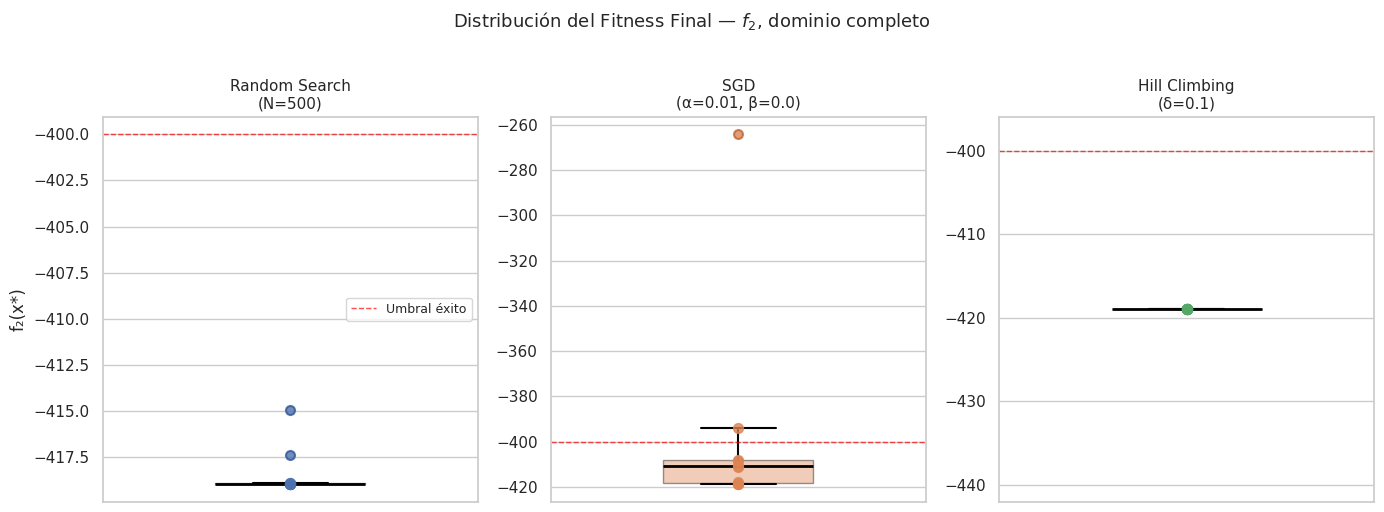

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
sns.set_theme(style='whitegrid')

datasets = [rs_y, sgd_y, hc_y]
titulos  = [
    f'Random Search\n(N={best_N_nc})',
    f'SGD\n(α={best_a_nc}, β={best_b_nc})',
    f'Hill Climbing\n(δ={best_d_nc})',
]
colores_list = ['#4C72B0', '#DD8452', '#55A868']

for ax, data, titulo, color in zip(axs, datasets, titulos, colores_list):
    ax.boxplot(data, patch_artist=True, widths=0.4,
               boxprops=dict(facecolor=color, alpha=0.4),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5))
    ax.scatter([1]*len(data), data, color=color, alpha=0.8, zorder=3, s=50)
    ax.axhline(-400, color='red', linestyle='--', linewidth=1,
               alpha=0.7, label='Umbral éxito')
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('f₂(x*)' if ax == axs[0] else '')
    ax.set_xticks([])

axs[0].legend(fontsize=9)
fig.suptitle('Distribución del Fitness Final — $f_2$, dominio completo',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


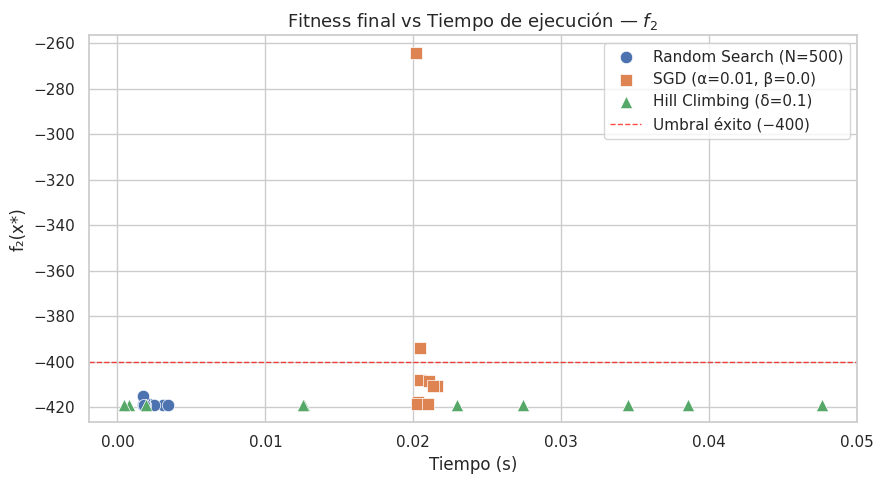

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.set_theme(style='whitegrid')

datos = [
    (rs_t,   rs_y,   '#4C72B0', 'o', f'Random Search (N={best_N_nc})'),
    (sgd_t,  sgd_y,  '#DD8452', 's', f'SGD (α={best_a_nc}, β={best_b_nc})'),
    (hc_t,   hc_y,   '#55A868', '^', f'Hill Climbing (δ={best_d_nc})'),
]

for ts, ys, color, marker, label in datos:
    ax.scatter(ts, ys, color=color, marker=marker, s=80,
               label=label, edgecolors='white', linewidths=0.5, zorder=3)

ax.axhline(-400, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label='Umbral éxito (−400)')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('f₂(x*)')
ax.set_title('Fitness final vs Tiempo de ejecución — $f_2$', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


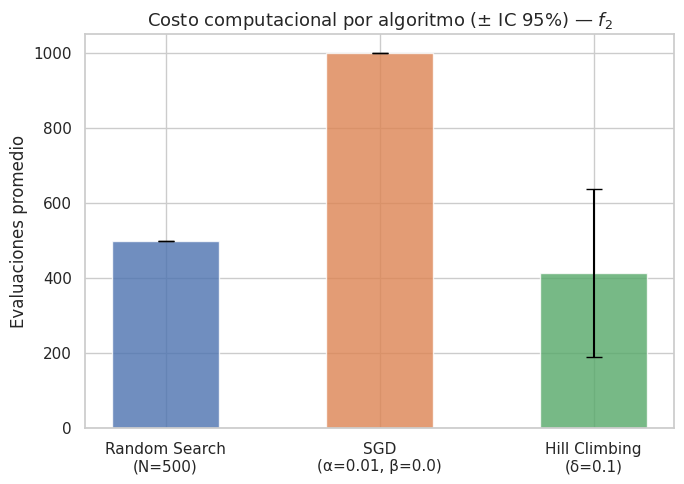

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.set_theme(style='whitegrid')

algoritmos = [
    f'Random Search\n(N={best_N_nc})',
    f'SGD\n(α={best_a_nc}, β={best_b_nc})',
    f'Hill Climbing\n(δ={best_d_nc})',
]
eval_datos = [
    [best_N_nc] * k_comp,
    sgd_eval,
    hc_eval,
]
colores_list = ['#4C72B0', '#DD8452', '#55A868']

medias = [np.mean(d) for d in eval_datos]
ics    = [1.96 * np.std(d, ddof=1) / np.sqrt(k_comp) for d in eval_datos]

bars = ax.bar(algoritmos, medias, color=colores_list, alpha=0.8,
              edgecolor='white', width=0.5)
ax.errorbar(algoritmos, medias, yerr=ics,
            fmt='none', color='black', capsize=6, linewidth=1.5)

ax.set_ylabel('Evaluaciones promedio')
ax.set_title('Costo computacional por algoritmo (± IC 95%) — $f_2$', fontsize=13)
plt.tight_layout()
plt.show()


**Análisis de los resultados**:

1. **Calidad de solución**: ¿Qué algoritmo encuentra el mejor fitness promedio? ¿Y la mediana más baja?

2. **Consistencia**: ¿Qué algoritmo tiene menor variabilidad (IC más estrecho, boxplot más compacto)?

3. **Tasa de éxito**: ¿Qué algoritmo logra la mayor proporción de soluciones "buenas" ($f < -400$)?

4. **Eficiencia computacional**: Considerando tanto evaluaciones como tiempo, ¿qué algoritmo ofrece mejor relación calidad/costo?

5. **Trade-offs**:
   - Random Search puede requerir muchas evaluaciones pero es robusto
   - SGD puede converger rápido pero quedar atrapado en óptimos locales
   - Hill Climbing converge muy rápido pero es el más vulnerable a óptimos locales
   
   ¿Cuál trade-off es más favorable en este problema?

6. **Ganador contextual**: ¿Hay un "ganador" absoluto, o la elección óptima depende de si priorizamos precisión, velocidad, o robustez?

7. **Comparación con la función convexa**: ¿Cómo cambió el ranking de los algoritmos al pasar de $f_1$ a $f_2$? ¿Qué nos dice esto sobre la importancia de las características del problema?

## Recursos Adicionales

### Visualización interactiva del proceso de búsqueda

El siguiente código muestra la estructura básica para implementar visualización en tiempo real del proceso de optimización:

```python
import matplotlib.pyplot as plt

plt.ion()  # Activar modo interactivo
fig, ax = plt.subplots(figsize=(10, 8))

for iteracion in range(max_iteraciones):
    # ... ejecutar paso del algoritmo ...
    
    
    #--------------------------------------------
    # GRAFICACION
    #-------------
    ax.clear()  # Limpiar gráfico anterior
    # ... graficar función objetivo (heatmap/contour/scatter/etc) ...
    # ... graficar soluciones actuales ...
    # ... graficar mejor solución ...
    # ... actualizar panel informativo ...
    
    plt.draw()
    plt.pause(0.05)  # Pausa de 50ms entre frames
    #--------------------------------------------
    
    
plt.ioff()  # Desactivar modo interactivo
plt.show()
```